In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/harshalkarangale/cl-encoder/pytorch/default/1/best_model.pt
/kaggle/input/models/harshalkarangale/cl-encoder-freeze/pytorch/default/1/best_model_freeze.pt
/kaggle/input/datasets/harshalkarangale/script2/500_summer_scenes_only.json
/kaggle/input/datasets/harshalkarangale/script2/avatar_scenes_only.json
/kaggle/input/datasets/harshalkarangale/script2/apocalypse_scenes_only.json
/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json
/kaggle/input/datasets/harshalkarangale/script1/avatar_scenes_only.json
/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json
/kaggle/input/datasets/harshalkarangale/avengers-multi/multi_avengers_scenes_only.json


Device: cuda
Loading scripts...
500 Days of Summer : 107 labelled scenes
Avatar             : 79 labelled scenes

Summer dist : Counter({'Negative_Distressing': 44, 'Neutral_Complex': 35, 'Positive_Uplifting': 27, 'Tension_Action': 1})
Avatar  dist: Counter({'Tension_Action': 34, 'Neutral_Complex': 20, 'Negative_Distressing': 19, 'Positive_Uplifting': 6})

Train: 172 scenes (Summer=107 + Avatar_train=65)
Test : 14 scenes (Avatar held-out)

Train dist: Counter({'Negative_Distressing': 57, 'Neutral_Complex': 49, 'Tension_Action': 35, 'Positive_Uplifting': 31})
Test  dist: Counter({'Negative_Distressing': 6, 'Neutral_Complex': 6, 'Positive_Uplifting': 2})


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Adapted model ready
  Trainable: 40,365,061 / 120,905,221  (33.4%)
Class weights: {'Positive_Uplifting': 1.39, 'Neutral_Complex': 0.88, 'Tension_Action': 1.23, 'Negative_Distressing': 0.75}
── Domain Adaptation Training ──
   Train: 172 scenes | Test: 14 scenes

Epoch  1/40  train_loss=1.4013  train_acc=0.244  test_loss=1.3803  test_acc=0.214  macro_f1=0.1978  gap=0.030
  ✓ New best saved  (macro_f1=0.1978)
Epoch  2/40  train_loss=1.3476  train_acc=0.326  test_loss=1.3686  test_acc=0.214  macro_f1=0.2500  gap=0.111
  ✓ New best saved  (macro_f1=0.2500)
Epoch  3/40  train_loss=1.2321  train_acc=0.477  test_loss=1.4242  test_acc=0.143  macro_f1=0.1786  gap=0.334
Epoch  4/40  train_loss=1.0745  train_acc=0.500  test_loss=1.4235  test_acc=0.286  macro_f1=0.4508  gap=0.214
  ✓ New best saved  (macro_f1=0.4508)
Epoch  5/40  train_loss=0.8849  train_acc=0.599  test_loss=1.7169  test_acc=0.143  macro_f1=0.1574  gap=0.456
Epoch  6/40  train_loss=0.7381  train_acc=0.674  test_loss=1.7515  test

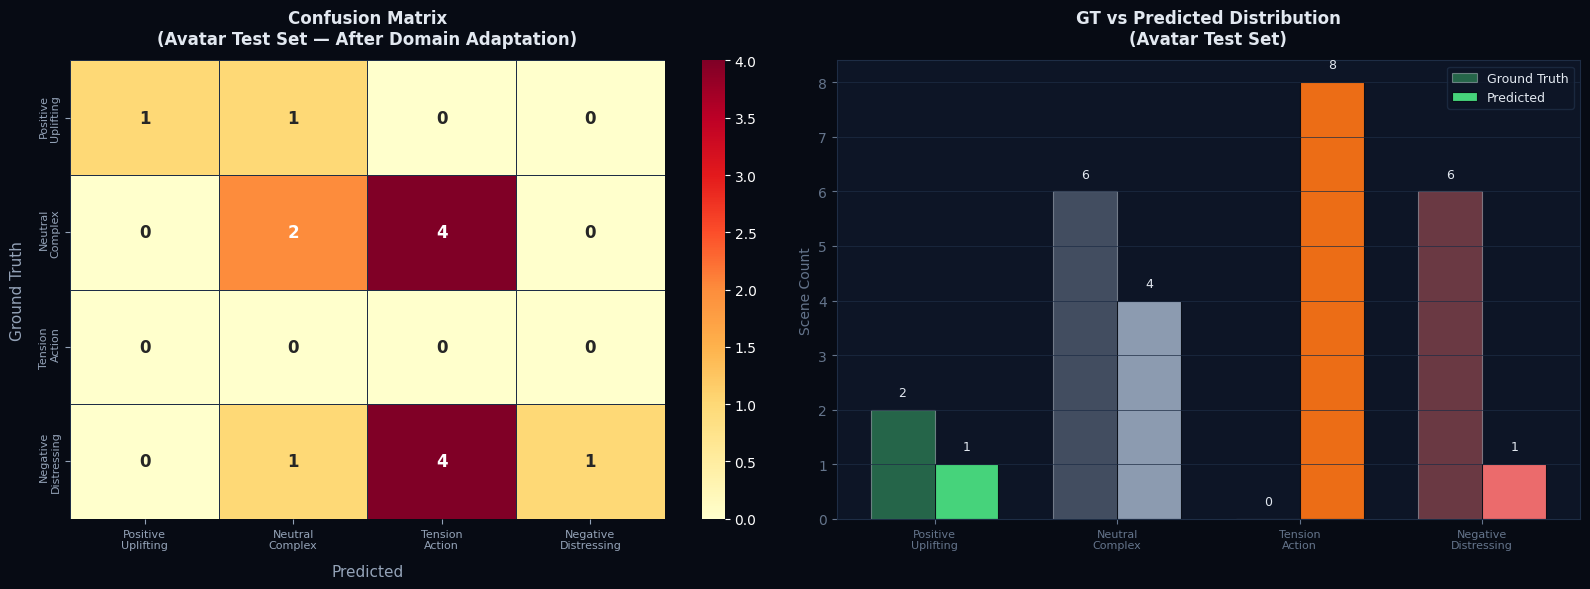


── Before vs After Domain Adaptation ──
  Before (GoEmotions only)           : Accuracy=34.0%  Macro F1=0.22
  After  (500Days + Avatar adapted)  : Accuracy=28.6%  Macro F1=0.4508

✓ Adapted model saved to: /kaggle/working/best_model_adapted.pt


In [7]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════
import json, math, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Config
# ═══════════════════════════════════════════════════════════════
MAX_LEN      = 128
BATCH_SIZE   = 8
DA_EPOCHS    = 40
PATIENCE     = 6
DA_DROPOUT   = 0.4
EMBED_DIM    = 768
NUM_HEADS    = 8
FF_DIM       = 2048
DROPOUT      = 0.2          # base model dropout (must match training)
NUM_CLASSES  = 9            # GoEmotions classes (base model output)

CORE_ORDER  = ["Positive_Uplifting", "Neutral_Complex",
               "Tension_Action",     "Negative_Distressing"]
CORE_TO_IDX = {c: i for i, c in enumerate(CORE_ORDER)}
NUM_CORE_CLASSES = len(CORE_ORDER)

CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

# ── Paths — change these to match your Kaggle dataset paths ──
MODEL_PATH       = "/kaggle/input/models/harshalkarangale/cl-encoder/pytorch/default/1/best_model.pt"
SUMMER_JSON_PATH = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"         # 500 Days of Summer
AVATAR_JSON_PATH = "/kaggle/input/datasets/harshalkarangale/script1/avatar_scenes_only.json"        # Avatar
ADAPTED_MODEL_PATH = "/kaggle/working/best_model_adapted.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════
#  CELL 3 — JSON loader (handles both formats)
# ═══════════════════════════════════════════════════════════════
def load_script_json(path):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()

    # Try direct parse first
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        # Unwrapped array — wrap it
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)

    # Unwrap if dict with scenes key
    if isinstance(data, dict):
        # Avatar format: {"script": "Avatar", "scenes": [...]}
        if "scenes" in data:
            data = data["scenes"]
        else:
            data = list(data.values())[0]

    # Extract labelled scenes with scene_text
    scenes = []
    for s in data:
        text = str(s.get("scene_text", "")).strip()
        core = s.get("emotional_core")
        if text and core is not None:
            scenes.append({
                "text"     : text,
                "core"     : core.strip(),
                "scene_id" : s.get("scene_id", "?"),
                "header"   : s.get("scene_header", "")
            })
    return scenes


print("Loading scripts...")
summer_scenes = load_script_json(SUMMER_JSON_PATH)
avatar_scenes = load_script_json(AVATAR_JSON_PATH)

print(f"500 Days of Summer : {len(summer_scenes)} labelled scenes")
print(f"Avatar             : {len(avatar_scenes)} labelled scenes")
print(f"\nSummer dist : {Counter(s['core'] for s in summer_scenes)}")
print(f"Avatar  dist: {Counter(s['core'] for s in avatar_scenes)}")

# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Split Avatar 70/30, use all of Summer for train
# ═══════════════════════════════════════════════════════════════
# Separate Tension_Action from Avatar (may be very few)
avatar_tension = [s for s in avatar_scenes if s["core"] == "Tension_Action"]
avatar_rest    = [s for s in avatar_scenes if s["core"] != "Tension_Action"]

av_texts  = [s["text"] for s in avatar_rest]
av_labels = [s["core"] for s in avatar_rest]

av_train_texts, av_test_texts, av_train_labels, av_test_labels = train_test_split(
    av_texts, av_labels,
    test_size=0.3,
    stratify=av_labels,
    random_state=42
)

# Add Tension_Action to train only (too few to split)
av_train_texts  += [s["text"] for s in avatar_tension]
av_train_labels += [s["core"] for s in avatar_tension]

# Final train = all Summer + 70% Avatar
train_texts  = [s["text"] for s in summer_scenes] + av_train_texts
train_labels = [s["core"] for s in summer_scenes] + av_train_labels

# Final test = 30% Avatar only (unseen movie)
test_texts  = av_test_texts
test_labels = av_test_labels

print(f"\nTrain: {len(train_texts)} scenes (Summer={len(summer_scenes)} + Avatar_train={len(av_train_texts)})")
print(f"Test : {len(test_texts)} scenes (Avatar held-out)")
print(f"\nTrain dist: {Counter(train_labels)}")
print(f"Test  dist: {Counter(test_labels)}")

# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Base model architecture (must match training exactly)
# ═══════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.head_dim  = embed_dim // num_heads
        self.num_heads = num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q       = nn.Linear(embed_dim, embed_dim)
        self.W_k       = nn.Linear(embed_dim, embed_dim)
        self.W_v       = nn.Linear(embed_dim, embed_dim)
        self.W_o       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, E = x.shape
        def split(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores   = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, E)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, heads=NUM_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(embed_dim, heads, dropout)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Tanh(), nn.Linear(256, 1)
        )
    def forward(self, x, mask=None):
        scores = self.scorer(x)
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, None] == 0, float("-inf"))
        return (torch.softmax(scores, dim=1) * x).sum(dim=1)


class EmotionTransformer(nn.Module):
    """Original base model — must match training exactly."""
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.enc1       = TransformerEncoderLayer()
        self.enc2       = TransformerEncoderLayer()
        self.pool       = AttentionPooling()
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        pooled = self.pool(x, mask=attention_mask)
        return self.classifier(pooled)

# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Adapted model (4-class head on top of pretrained)
# ═══════════════════════════════════════════════════════════════
class AdaptedEmotionModel(nn.Module):
    def __init__(self, base, num_classes=NUM_CORE_CLASSES):
        super().__init__()
        self.bert = base.bert
        self.enc1 = base.enc1
        self.enc2 = base.enc2
        self.pool = base.pool
        # New 4-class head
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 256), nn.GELU(),
            nn.Dropout(DA_DROPOUT),   nn.Linear(256, num_classes)
        )
        # Freeze bottom 8 BERT layers
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        for i in range(8):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
        # Top 4 layers trainable
        for i in range(8, 12):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        pooled = self.pool(x, mask=attention_mask)
        return self.classifier(pooled)


tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
base_model = EmotionTransformer(num_classes=NUM_CLASSES).to(device)
state      = torch.load(MODEL_PATH, map_location=device, weights_only=True)
base_model.load_state_dict(state)

da_model = AdaptedEmotionModel(base_model).to(device)

total     = sum(p.numel() for p in da_model.parameters())
trainable = sum(p.numel() for p in da_model.parameters() if p.requires_grad)
print(f"✓ Adapted model ready")
print(f"  Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)")

# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Dataset + DataLoaders
# ═══════════════════════════════════════════════════════════════
class CoreDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = [str(t) for t in texts]
        self.labels = [CORE_TO_IDX[l] for l in labels]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], padding="max_length",
            truncation=True, max_length=MAX_LEN, return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


train_loader_da = DataLoader(CoreDataset(train_texts, train_labels),
                              batch_size=BATCH_SIZE, shuffle=True)
test_loader_da  = DataLoader(CoreDataset(test_texts,  test_labels),
                              batch_size=BATCH_SIZE, shuffle=False)

# ═══════════════════════════════════════════════════════════════
#  CELL 8 — Loss + Optimizer + Scheduler
# ═══════════════════════════════════════════════════════════════
# Class weights from train distribution
train_dist  = Counter(train_labels)
total_train = len(train_labels)
weights     = torch.tensor(
    [total_train / (NUM_CORE_CLASSES * train_dist.get(c, 1)) for c in CORE_ORDER],
    dtype=torch.float
).to(device)
print(f"Class weights: { {c: round(w.item(),2) for c,w in zip(CORE_ORDER, weights)} }")

criterion_da = nn.CrossEntropyLoss(weight=weights)

bert_top_params = (list(da_model.bert.encoder.layer[8:].parameters()) +
                   list(da_model.bert.pooler.parameters()))
custom_params   = (list(da_model.enc1.parameters()) +
                   list(da_model.enc2.parameters()) +
                   list(da_model.pool.parameters()) +
                   list(da_model.classifier.parameters()))

optimizer_da = optim.AdamW([
    {"params": bert_top_params, "lr": 1e-5, "weight_decay": 0.01},
    {"params": custom_params,   "lr": 5e-5, "weight_decay": 0.01},
])

total_steps  = len(train_loader_da) * DA_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler_da = get_cosine_schedule_with_warmup(optimizer_da, warmup_steps, total_steps)

# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Train / Eval functions
# ═══════════════════════════════════════════════════════════════
def da_train_epoch():
    da_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for input_ids, mask, labels in train_loader_da:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        optimizer_da.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(da_model.parameters(), 1.0)
        optimizer_da.step()
        scheduler_da.step()
        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(train_loader_da), correct / total


@torch.no_grad()
def da_eval_epoch(loader):
    da_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for input_ids, mask, labels in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.cpu().tolist()

    pred_names  = [CORE_ORDER[p] for p in all_preds]
    label_names = [CORE_ORDER[l] for l in all_labels]

    # Macro F1 on classes that exist in this split
    present = list(set(label_names))
    macro_f1 = f1_score(label_names, pred_names,
                        labels=present, average="macro", zero_division=0)
    return total_loss / len(loader), correct / total, macro_f1, pred_names, label_names

# ═══════════════════════════════════════════════════════════════
#  CELL 10 — Training loop
# ═══════════════════════════════════════════════════════════════
print("── Domain Adaptation Training ──")
print(f"   Train: {len(train_texts)} scenes | Test: {len(test_texts)} scenes\n")

best_f1_da, best_state_da, patience_counter = 0.0, None, 0

for epoch in range(1, DA_EPOCHS + 1):
    tr_loss, tr_acc                        = da_train_epoch()
    te_loss, te_acc, te_f1, preds, labels  = da_eval_epoch(test_loader_da)
    gap = tr_acc - te_acc

    print(f"Epoch {epoch:2d}/{DA_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
          f"test_loss={te_loss:.4f}  test_acc={te_acc:.3f}  "
          f"macro_f1={te_f1:.4f}  gap={gap:.3f}")

    if te_f1 > best_f1_da:
        best_f1_da       = te_f1
        best_state_da    = {k: v.cpu().clone() for k, v in da_model.state_dict().items()}
        patience_counter = 0
        torch.save(best_state_da, ADAPTED_MODEL_PATH)
        print(f"  ✓ New best saved  (macro_f1={best_f1_da:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ═══════════════════════════════════════════════════════════════
#  CELL 11 — Final evaluation + plots
# ═══════════════════════════════════════════════════════════════
print("\n── Final Test Evaluation (Avatar held-out 30%) ──")
da_model.load_state_dict({k: v.to(device) for k, v in best_state_da.items()})
_, test_acc, test_f1, pred_names, label_names = da_eval_epoch(test_loader_da)

print(f"Accuracy  : {test_acc*100:.1f}%")
print(f"Macro F1  : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(label_names, pred_names,
                             labels=CORE_ORDER, zero_division=0))

# ── Confusion matrix ──
cm = confusion_matrix(label_names, pred_names, labels=CORE_ORDER)
plt.style.use("dark_background")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#070b14")

ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix\n(Avatar Test Set — After Domain Adaptation)",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── GT vs Pred distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(label_names)
pred_dist = Counter(pred_names)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]

b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)

for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")

ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count", color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution\n(Avatar Test Set)",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/domain_adaptation_results.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

print(f"\n── Before vs After Domain Adaptation ──")
print(f"  Before (GoEmotions only)           : Accuracy=34.0%  Macro F1=0.22")
print(f"  After  (500Days + Avatar adapted)  : Accuracy={test_acc*100:.1f}%  Macro F1={test_f1:.4f}")
print(f"\n✓ Adapted model saved to: {ADAPTED_MODEL_PATH}")

In [11]:
# ── Check distribution of all 3 scripts ──
import json, re
from collections import Counter

def load_script_json(path):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)
    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])
    scenes = []
    for s in data:
        text = str(s.get("scene_text", "")).strip()
        core = s.get("emotional_core")
        if text and core is not None:
            scenes.append({
                "text"  : text,
                "core"  : core.strip(),
                "scene_id": s.get("scene_id", "?")
            })
    return scenes

# ── Change these paths ──
SUMMER_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"
AVATAR_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/avatar_scenes_only.json"
AVENGERS_PATH = "/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json

"  # ← change

summer_scenes   = load_script_json(SUMMER_PATH)
avatar_scenes   = load_script_json(AVATAR_PATH)
avengers_scenes = load_script_json(AVENGERS_PATH)

CORE_ORDER = ["Positive_Uplifting", "Neutral_Complex",
              "Tension_Action",     "Negative_Distressing"]

def print_dist(name, scenes):
    dist  = Counter(s["core"] for s in scenes)
    total = len(scenes)
    print(f"\n{name}  ({total} scenes)")
    print(f"  {'Core':<25} {'Count':>6}  {'%':>6}")
    print(f"  {'─'*40}")
    for c in CORE_ORDER:
        n   = dist.get(c, 0)
        pct = n / total * 100 if total > 0 else 0
        print(f"  {c:<25} {n:>6}  {pct:>5.1f}%")
    print(f"  {'─'*40}")
    print(f"  {'TOTAL':<25} {total:>6}")

print_dist("500 Days of Summer", summer_scenes)
print_dist("Avatar",             avatar_scenes)
print_dist("Avengers",           avengers_scenes)

print(f"\n── Combined Total ──")
all_scenes = summer_scenes + avatar_scenes + avengers_scenes
print_dist("ALL SCRIPTS", all_scenes)


500 Days of Summer  (107 scenes)
  Core                       Count       %
  ────────────────────────────────────────
  Positive_Uplifting            27   25.2%
  Neutral_Complex               35   32.7%
  Tension_Action                 1    0.9%
  Negative_Distressing          44   41.1%
  ────────────────────────────────────────
  TOTAL                        107

Avatar  (79 scenes)
  Core                       Count       %
  ────────────────────────────────────────
  Positive_Uplifting             6    7.6%
  Neutral_Complex               20   25.3%
  Tension_Action                34   43.0%
  Negative_Distressing          19   24.1%
  ────────────────────────────────────────
  TOTAL                         79

Avengers  (172 scenes)
  Core                       Count       %
  ────────────────────────────────────────
  Positive_Uplifting            20   11.6%
  Neutral_Complex               36   20.9%
  Tension_Action                65   37.8%
  Negative_Distressing          46

Device: cuda
500 Days of Summer : 107 scenes
Avatar             : 79 scenes
Avengers           : 172 scenes
Total              : 358 scenes
✓ Total usable scenes after mapping: 358
  Combined dist: Counter({'Negative_Distressing': 109, 'Tension_Action': 100, 'Neutral_Complex': 91, 'Positive_Uplifting': 58})

Train : 286 scenes
Test  : 72  scenes

Train dist : Counter({'Negative_Distressing': 87, 'Tension_Action': 80, 'Neutral_Complex': 73, 'Positive_Uplifting': 46})
Test  dist : Counter({'Negative_Distressing': 22, 'Tension_Action': 20, 'Neutral_Complex': 18, 'Positive_Uplifting': 12})

Test source breakdown:
  Avatar     | Negative_Distressing      : 3
  Avatar     | Neutral_Complex           : 5
  Avatar     | Positive_Uplifting        : 1
  Avatar     | Tension_Action            : 10
  Avengers   | Negative_Distressing      : 11
  Avengers   | Neutral_Complex           : 5
  Avengers   | Positive_Uplifting        : 7
  Avengers   | Tension_Action            : 9
  Summer     | Negati

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Adapted model ready
  Trainable: 40,365,061 / 120,905,221  (33.4%)
Class weights: {'Positive_Uplifting': 1.55, 'Neutral_Complex': 0.98, 'Tension_Action': 0.89, 'Negative_Distressing': 0.82}
── Domain Adaptation Training ──
   Train: 286 | Test: 72

Epoch  1/40  train_loss=1.4164  train_acc=0.308  test_loss=1.3778  test_acc=0.431  macro_f1=0.3063  gap=-0.123
  ✓ New best saved  (macro_f1=0.3063)
Epoch  2/40  train_loss=1.3473  train_acc=0.385  test_loss=1.3519  test_acc=0.319  macro_f1=0.3043  gap=0.065
Epoch  3/40  train_loss=1.2294  train_acc=0.448  test_loss=1.3135  test_acc=0.333  macro_f1=0.2824  gap=0.114
Epoch  4/40  train_loss=1.1007  train_acc=0.556  test_loss=1.3339  test_acc=0.347  macro_f1=0.3302  gap=0.209
  ✓ New best saved  (macro_f1=0.3302)
Epoch  5/40  train_loss=0.8956  train_acc=0.629  test_loss=1.3511  test_acc=0.403  macro_f1=0.4018  gap=0.227
  ✓ New best saved  (macro_f1=0.4018)
Epoch  6/40  train_loss=0.7669  train_acc=0.703  test_loss=1.3517  test_acc=0.417  m

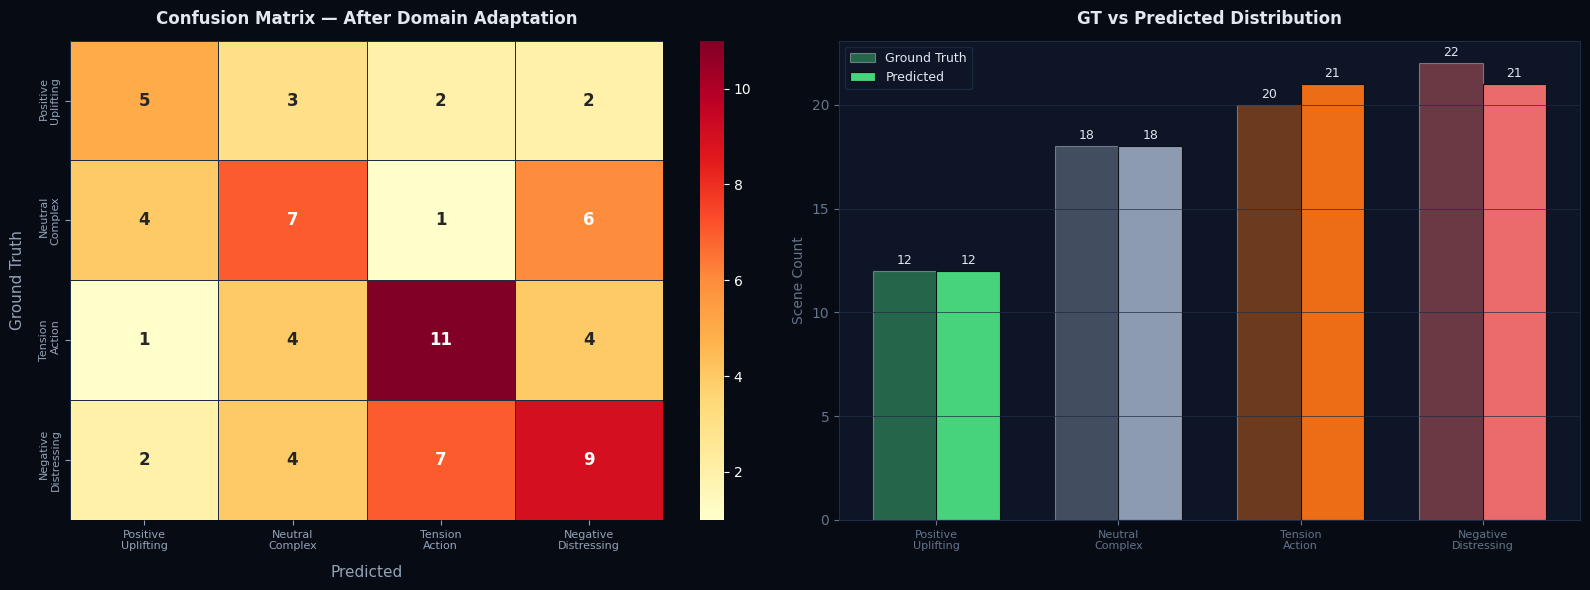

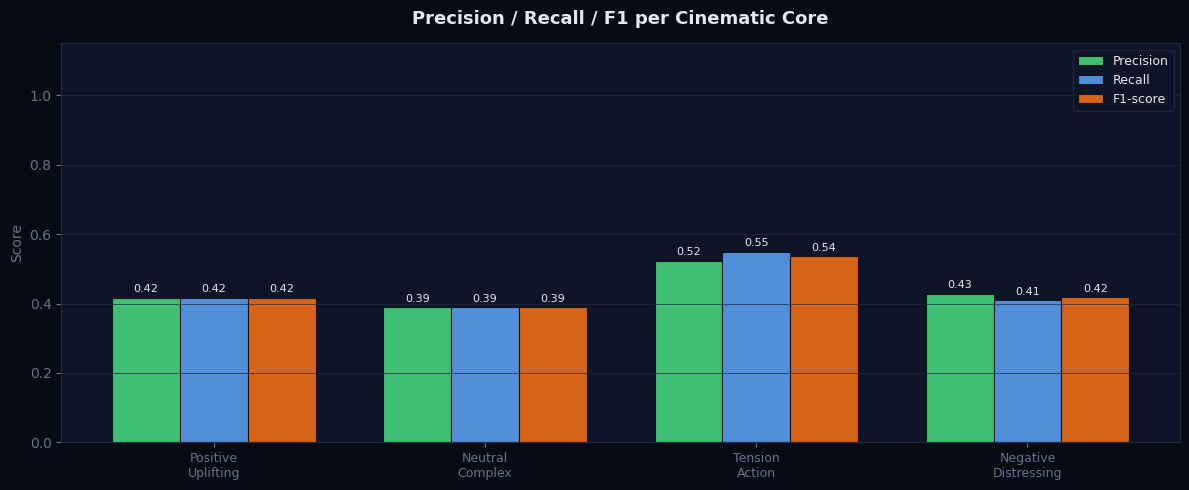


── Before vs After Domain Adaptation ──
  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22
  After  (Summer + Avatar + Avengers DA)  : Accuracy=44.4%  Macro F1=0.4402

✓ Adapted model saved: /kaggle/working/best_model_adapted.pt


In [18]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════
import json, math, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Config
# ═══════════════════════════════════════════════════════════════
MAX_LEN          = 128
BATCH_SIZE       = 8
DA_EPOCHS        = 40
PATIENCE         = 7
DA_DROPOUT       = 0.4
EMBED_DIM        = 768
NUM_HEADS        = 8
FF_DIM           = 2048
DROPOUT          = 0.2        # must match base model training
NUM_CLASSES      = 9          # base model GoEmotions output size

CORE_ORDER       = ["Positive_Uplifting", "Neutral_Complex",
                    "Tension_Action",     "Negative_Distressing"]
CORE_TO_IDX      = {c: i for i, c in enumerate(CORE_ORDER)}
NUM_CORE_CLASSES = len(CORE_ORDER)

CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

# ── Paths ──
MODEL_PATH         = "/kaggle/input/models/harshalkarangale/cl-encoder/pytorch/default/1/best_model.pt"
SUMMER_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"
AVATAR_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/avatar_scenes_only.json"
AVENGERS_PATH = "/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json"
ADAPTED_MODEL_PATH = "/kaggle/working/best_model_adapted.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════
#  CELL 3 — JSON loader
# ═══════════════════════════════════════════════════════════════
def load_script_json(path, name=""):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)
    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])
    scenes = []
    for s in data:
        text = str(s.get("scene_text", "")).strip()
        core = s.get("emotional_core")
        if text and core is not None:
            scenes.append({
                "text"  : text,
                "core"  : core.strip(),
                "source": name
            })
    return scenes

summer_scenes   = load_script_json(SUMMER_PATH,   "Summer")
avatar_scenes   = load_script_json(AVATAR_PATH,   "Avatar")
avengers_scenes = load_script_json(AVENGERS_PATH, "Avengers")

print(f"500 Days of Summer : {len(summer_scenes)} scenes")
print(f"Avatar             : {len(avatar_scenes)} scenes")
print(f"Avengers           : {len(avengers_scenes)} scenes")
print(f"Total              : {len(summer_scenes)+len(avatar_scenes)+len(avengers_scenes)} scenes")

# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Extended core mapping + Stratified 80/20 split
# ═══════════════════════════════════════════════════════════════

# Map any extra labels found in Avengers (or other scripts)
# to one of our 4 canonical cores
EXTENDED_CORE_MAP = {
    # Already valid — pass through
    "Positive_Uplifting"   : "Positive_Uplifting",
    "Neutral_Complex"      : "Neutral_Complex",
    "Tension_Action"       : "Tension_Action",
    "Negative_Distressing" : "Negative_Distressing",

    # Avengers extras
    "Awe_Wonder"           : "Positive_Uplifting",
    "Heroic_Triumph"       : "Positive_Uplifting",
    "Epic_Grandiose"       : "Tension_Action",
    "Dread_Fear"           : "Negative_Distressing",
    "Sacrifice"            : "Negative_Distressing",
    "Grief_Loss"           : "Negative_Distressing",
    "Anger_Defiance"       : "Tension_Action",
    "Suspense_Unease"      : "Tension_Action",
    "Determination"        : "Tension_Action",
    "Relief_Catharsis"     : "Positive_Uplifting",
    "Melancholy_Longing"   : "Negative_Distressing",
    "Humor_Levity"         : "Positive_Uplifting",
    "Shock_Disbelief"      : "Negative_Distressing",
    "Camaraderie_Bonding"  : "Positive_Uplifting",
    "Urgency_Desperation"  : "Tension_Action",

    # annoyance → Negative_Distressing (not Tension_Action)
    "annoyance"            : "Negative_Distressing",
}

def map_core(raw_core):
    """Map raw emotional_core to one of our 4 canonical cores."""
    raw = raw_core.strip()
    if raw in EXTENDED_CORE_MAP:
        return EXTENDED_CORE_MAP[raw]
    return None   # unknown — will be filtered out

# Apply mapping to all scenes
all_raw    = summer_scenes + avatar_scenes + avengers_scenes
all_scenes = []
skipped    = Counter()

for s in all_raw:
    mapped = map_core(s["core"])
    if mapped is not None:
        all_scenes.append({
            "text"  : s["text"],
            "core"  : mapped,
            "source": s["source"]
        })
    else:
        skipped[s["core"]] += 1

if skipped:
    print(f"⚠ Skipped {sum(skipped.values())} scenes with unmapped cores: {dict(skipped)}")
print(f"✓ Total usable scenes after mapping: {len(all_scenes)}")
print(f"  Combined dist: {Counter(s['core'] for s in all_scenes)}")

all_texts  = [s["text"]   for s in all_scenes]
all_labels = [s["core"]   for s in all_scenes]
all_source = [s["source"] for s in all_scenes]

train_texts, test_texts, train_labels, test_labels, train_src, test_src = train_test_split(
    all_texts, all_labels, all_source,
    test_size    = 0.2,
    stratify     = all_labels,
    random_state = 42
)

print(f"\nTrain : {len(train_texts)} scenes")
print(f"Test  : {len(test_texts)}  scenes")

print(f"\nTrain dist : {Counter(train_labels)}")
print(f"Test  dist : {Counter(test_labels)}")

print(f"\nTest source breakdown:")
test_src_core = Counter(zip(test_src, test_labels))
for (src, core), count in sorted(test_src_core.items()):
    print(f"  {src:10s} | {core:25s} : {count}")

# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Base model architecture (exact match to training)
# ═══════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.head_dim  = embed_dim // num_heads
        self.num_heads = num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q       = nn.Linear(embed_dim, embed_dim)
        self.W_k       = nn.Linear(embed_dim, embed_dim)
        self.W_v       = nn.Linear(embed_dim, embed_dim)
        self.W_o       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, E = x.shape
        def split(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores   = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, E)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, heads=NUM_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(embed_dim, heads, dropout)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Tanh(), nn.Linear(256, 1)
        )
    def forward(self, x, mask=None):
        scores = self.scorer(x)
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, None] == 0, float("-inf"))
        return (torch.softmax(scores, dim=1) * x).sum(dim=1)


class EmotionTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.enc1       = TransformerEncoderLayer()
        self.enc2       = TransformerEncoderLayer()
        self.pool       = AttentionPooling()
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )
    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))

# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Adapted model (4-class head)
# ═══════════════════════════════════════════════════════════════
class AdaptedEmotionModel(nn.Module):
    def __init__(self, base, num_classes=NUM_CORE_CLASSES):
        super().__init__()
        self.bert = base.bert
        self.enc1 = base.enc1
        self.enc2 = base.enc2
        self.pool = base.pool
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 256), nn.GELU(),
            nn.Dropout(DA_DROPOUT),   nn.Linear(256, num_classes)
        )
        # Freeze bottom 8 BERT layers
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        for i in range(8):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
        # Top 4 BERT layers trainable
        for i in range(8, 12):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))


tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
base_model = EmotionTransformer(num_classes=NUM_CLASSES).to(device)
state      = torch.load(MODEL_PATH, map_location=device, weights_only=True)
base_model.load_state_dict(state)

da_model   = AdaptedEmotionModel(base_model).to(device)
total      = sum(p.numel() for p in da_model.parameters())
trainable  = sum(p.numel() for p in da_model.parameters() if p.requires_grad)
print(f"✓ Adapted model ready")
print(f"  Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)")

# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Dataset + DataLoaders
# ═══════════════════════════════════════════════════════════════
class CoreDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = [str(t) for t in texts]
        self.labels = [CORE_TO_IDX[l] for l in labels]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], padding="max_length",
            truncation=True, max_length=MAX_LEN, return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_loader_da = DataLoader(CoreDataset(train_texts, train_labels),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
test_loader_da  = DataLoader(CoreDataset(test_texts, test_labels),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

# ═══════════════════════════════════════════════════════════════
#  CELL 8 — Loss + Optimizer + Scheduler
# ═══════════════════════════════════════════════════════════════
train_dist  = Counter(train_labels)
total_train = len(train_labels)
weights     = torch.tensor(
    [total_train / (NUM_CORE_CLASSES * train_dist.get(c, 1)) for c in CORE_ORDER],
    dtype=torch.float
).to(device)
print(f"Class weights: { {c: round(w.item(), 2) for c, w in zip(CORE_ORDER, weights)} }")

criterion_da = nn.CrossEntropyLoss(weight=weights)

bert_top_params = (list(da_model.bert.encoder.layer[8:].parameters()) +
                   list(da_model.bert.pooler.parameters()))
custom_params   = (list(da_model.enc1.parameters()) +
                   list(da_model.enc2.parameters()) +
                   list(da_model.pool.parameters()) +
                   list(da_model.classifier.parameters()))

optimizer_da = optim.AdamW([
    {"params": bert_top_params, "lr": 1e-5, "weight_decay": 0.01},
    {"params": custom_params,   "lr": 5e-5, "weight_decay": 0.01},
])

total_steps  = len(train_loader_da) * DA_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler_da = get_cosine_schedule_with_warmup(optimizer_da, warmup_steps, total_steps)

# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Train / Eval functions
# ═══════════════════════════════════════════════════════════════
def da_train_epoch():
    da_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for input_ids, mask, labels in train_loader_da:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        optimizer_da.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(da_model.parameters(), 1.0)
        optimizer_da.step()
        scheduler_da.step()
        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(train_loader_da), correct / total


@torch.no_grad()
def da_eval_epoch(loader):
    da_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for input_ids, mask, labels in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.cpu().tolist()
    pred_names  = [CORE_ORDER[p] for p in all_preds]
    label_names = [CORE_ORDER[l] for l in all_labels]
    macro_f1    = f1_score(label_names, pred_names,
                           labels=CORE_ORDER, average="macro", zero_division=0)
    return total_loss / len(loader), correct / total, macro_f1, pred_names, label_names

# ═══════════════════════════════════════════════════════════════
#  CELL 10 — Training loop
# ═══════════════════════════════════════════════════════════════
print(f"── Domain Adaptation Training ──")
print(f"   Train: {len(train_texts)} | Test: {len(test_texts)}\n")

best_f1_da, best_state_da, patience_counter = 0.0, None, 0

for epoch in range(1, DA_EPOCHS + 1):
    tr_loss, tr_acc                        = da_train_epoch()
    te_loss, te_acc, te_f1, preds, labels  = da_eval_epoch(test_loader_da)
    gap = tr_acc - te_acc

    print(f"Epoch {epoch:2d}/{DA_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
          f"test_loss={te_loss:.4f}  test_acc={te_acc:.3f}  "
          f"macro_f1={te_f1:.4f}  gap={gap:.3f}")

    if te_f1 > best_f1_da:
        best_f1_da       = te_f1
        best_state_da    = {k: v.cpu().clone() for k, v in da_model.state_dict().items()}
        patience_counter = 0
        torch.save(best_state_da, ADAPTED_MODEL_PATH)
        print(f"  ✓ New best saved  (macro_f1={best_f1_da:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ═══════════════════════════════════════════════════════════════
#  CELL 11 — Final evaluation + all plots
# ═══════════════════════════════════════════════════════════════
print("\n── Final Test Evaluation ──")
da_model.load_state_dict({k: v.to(device) for k, v in best_state_da.items()})
_, test_acc, test_f1, pred_names, label_names = da_eval_epoch(test_loader_da)

print(f"Accuracy  : {test_acc*100:.1f}%")
print(f"Macro F1  : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(label_names, pred_names,
                             labels=CORE_ORDER, zero_division=0))

plt.style.use("dark_background")

# ── Plot 1: Confusion Matrix ──
cm  = confusion_matrix(label_names, pred_names, labels=CORE_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#070b14")

ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix — After Domain Adaptation",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── Plot 2: GT vs Predicted distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(label_names)
pred_dist = Counter(pred_names)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]

b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count",   color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/da_results.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

# ── Plot 3: Per-class F1 bar chart ──
report_dict = classification_report(
    label_names, pred_names, labels=CORE_ORDER,
    zero_division=0, output_dict=True
)
metrics       = ["precision", "recall", "f1-score"]
metric_colors = ["#4ade80",   "#60a5fa", "#f97316"]
x             = np.arange(len(CORE_ORDER))
bw            = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#070b14")
ax.set_facecolor("#0d1526")
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report_dict[c][metric] for c in CORE_ORDER]
    bars = ax.bar(x + i * bw, vals, bw, label=metric.capitalize(),
                  color=color, alpha=0.85, edgecolor="#070b14", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=8, color="#e2e8f0")

ax.set_xticks(x + bw)
ax.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                   fontsize=9, color="#94a3b8")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", color="#64748b", fontsize=10)
ax.set_title("Precision / Recall / F1 per Cinematic Core",
             color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(colors="#64748b")
ax.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/per_class_f1.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

print(f"\n── Before vs After Domain Adaptation ──")
print(f"  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22")
print(f"  After  (Summer + Avatar + Avengers DA)  : Accuracy={test_acc*100:.1f}%  Macro F1={test_f1:.4f}")
print(f"\n✓ Adapted model saved: {ADAPTED_MODEL_PATH}")

Device: cuda
500 Days of Summer : 107 scenes
Avatar             : 79 scenes
Avengers           : 172 scenes
Total              : 358 scenes
✓ Total usable scenes after mapping: 358
  Combined dist: Counter({'Negative_Distressing': 109, 'Tension_Action': 100, 'Neutral_Complex': 91, 'Positive_Uplifting': 58})

Train : 286 scenes
Test  : 72  scenes

Train dist : Counter({'Negative_Distressing': 87, 'Tension_Action': 80, 'Neutral_Complex': 73, 'Positive_Uplifting': 46})
Test  dist : Counter({'Negative_Distressing': 22, 'Tension_Action': 20, 'Neutral_Complex': 18, 'Positive_Uplifting': 12})

Test source breakdown:
  Avatar     | Negative_Distressing      : 3
  Avatar     | Neutral_Complex           : 5
  Avatar     | Positive_Uplifting        : 1
  Avatar     | Tension_Action            : 10
  Avengers   | Negative_Distressing      : 11
  Avengers   | Neutral_Complex           : 5
  Avengers   | Positive_Uplifting        : 7
  Avengers   | Tension_Action            : 9
  Summer     | Negati

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Adapted model ready
  Trainable: 40,365,061 / 120,905,221  (33.4%)
Class weights: {'Positive_Uplifting': 1.55, 'Neutral_Complex': 0.98, 'Tension_Action': 0.89, 'Negative_Distressing': 0.82}
── Domain Adaptation Training ──
   Train: 286 | Test: 72

Epoch  1/40  train_loss=1.3913  train_acc=0.283  test_loss=1.3826  test_acc=0.278  macro_f1=0.1761  gap=0.005
  ✓ New best saved  (macro_f1=0.1761)
Epoch  2/40  train_loss=1.3220  train_acc=0.388  test_loss=1.3400  test_acc=0.361  macro_f1=0.3246  gap=0.027
  ✓ New best saved  (macro_f1=0.3246)
Epoch  3/40  train_loss=1.1959  train_acc=0.486  test_loss=1.3181  test_acc=0.375  macro_f1=0.3205  gap=0.111
Epoch  4/40  train_loss=1.0473  train_acc=0.559  test_loss=1.3317  test_acc=0.431  macro_f1=0.4323  gap=0.129
  ✓ New best saved  (macro_f1=0.4323)
Epoch  5/40  train_loss=0.8597  train_acc=0.622  test_loss=1.3942  test_acc=0.389  macro_f1=0.3617  gap=0.233
Epoch  6/40  train_loss=0.7270  train_acc=0.720  test_loss=1.4866  test_acc=0.361  ma

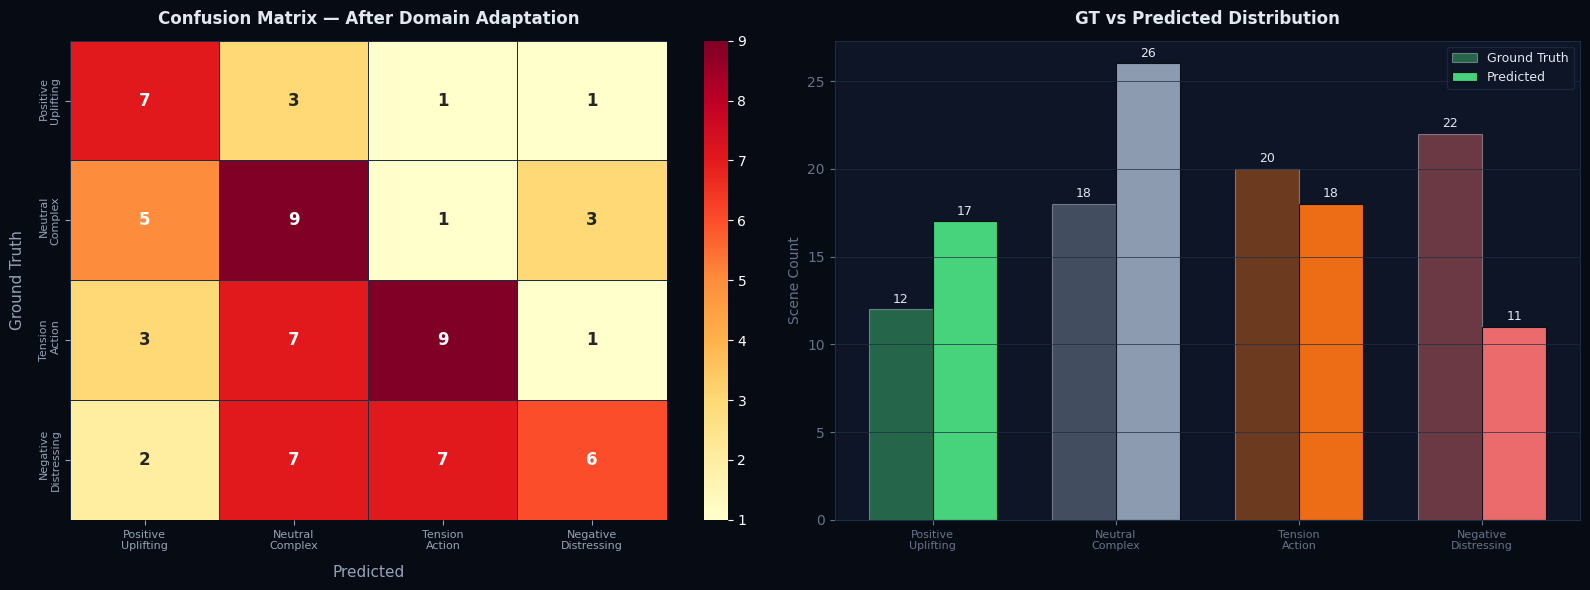

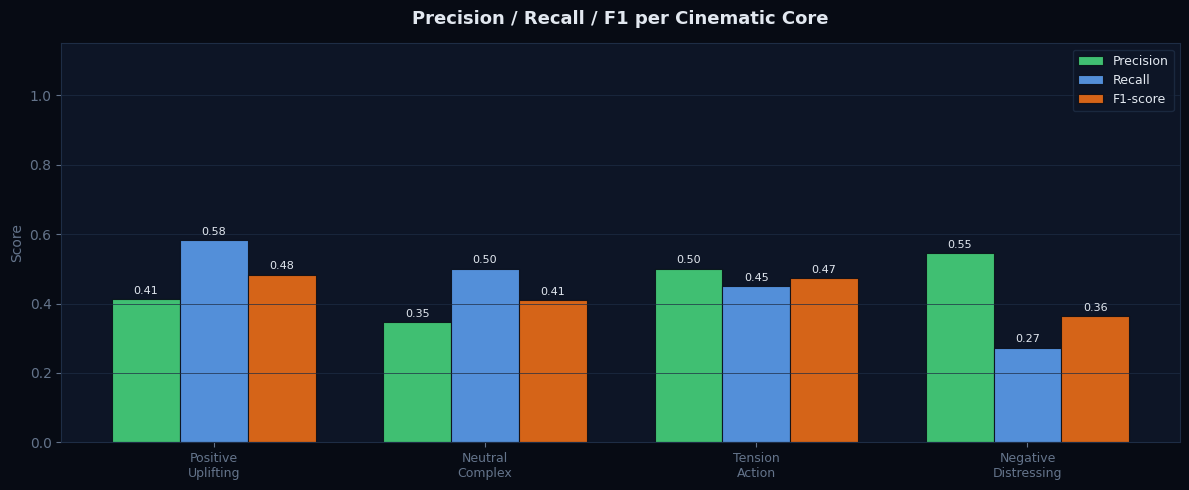


── Before vs After Domain Adaptation ──
  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22
  After  (Summer + Avatar + Avengers DA)  : Accuracy=43.1%  Macro F1=0.4323

✓ Adapted model saved: /kaggle/working/best_model_adapted.pt


In [19]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════
import json, math, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Config
# ═══════════════════════════════════════════════════════════════
MAX_LEN          = 128
BATCH_SIZE       = 8
DA_EPOCHS        = 40
PATIENCE         = 7
DA_DROPOUT       = 0.4
EMBED_DIM        = 768
NUM_HEADS        = 8
FF_DIM           = 2048
DROPOUT          = 0.2        # must match base model training
NUM_CLASSES      = 9          # base model GoEmotions output size

CORE_ORDER       = ["Positive_Uplifting", "Neutral_Complex",
                    "Tension_Action",     "Negative_Distressing"]
CORE_TO_IDX      = {c: i for i, c in enumerate(CORE_ORDER)}
NUM_CORE_CLASSES = len(CORE_ORDER)

CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

# ── Paths ──
MODEL_PATH         = "/kaggle/input/models/harshalkarangale/cl-encoder/pytorch/default/1/best_model.pt"
SUMMER_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"
AVATAR_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/avatar_scenes_only.json"
AVENGERS_PATH = "/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json"
ADAPTED_MODEL_PATH = "/kaggle/working/best_model_adapted.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════
#  CELL 3 — JSON loader
# ═══════════════════════════════════════════════════════════════
def load_script_json(path, name=""):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)
    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])
    scenes = []
    for s in data:
        text = str(s.get("scene_text", "")).strip()
        core = s.get("emotional_core")
        if text and core is not None:
            scenes.append({
                "text"  : text,
                "core"  : core.strip(),
                "source": name
            })
    return scenes

summer_scenes   = load_script_json(SUMMER_PATH,   "Summer")
avatar_scenes   = load_script_json(AVATAR_PATH,   "Avatar")
avengers_scenes = load_script_json(AVENGERS_PATH, "Avengers")

print(f"500 Days of Summer : {len(summer_scenes)} scenes")
print(f"Avatar             : {len(avatar_scenes)} scenes")
print(f"Avengers           : {len(avengers_scenes)} scenes")
print(f"Total              : {len(summer_scenes)+len(avatar_scenes)+len(avengers_scenes)} scenes")

# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Extended core mapping + Stratified 80/20 split
# ═══════════════════════════════════════════════════════════════

# Map any extra labels found in Avengers (or other scripts)
# to one of our 4 canonical cores
EXTENDED_CORE_MAP = {
    # Already valid — pass through
    "Positive_Uplifting"   : "Positive_Uplifting",
    "Neutral_Complex"      : "Neutral_Complex",
    "Tension_Action"       : "Tension_Action",
    "Negative_Distressing" : "Negative_Distressing",

    # Avengers extras
    "Awe_Wonder"           : "Positive_Uplifting",
    "Heroic_Triumph"       : "Positive_Uplifting",
    "Epic_Grandiose"       : "Tension_Action",
    "Dread_Fear"           : "Negative_Distressing",
    "Sacrifice"            : "Negative_Distressing",
    "curiosity"   : "Tension_Action",         # was missing
    "Grief_Loss"           : "Negative_Distressing",
    "Anger_Defiance"       : "Tension_Action",
    "Suspense_Unease"      : "Tension_Action",
    "Determination"        : "Tension_Action",
    "Relief_Catharsis"     : "Positive_Uplifting",
    "Melancholy_Longing"   : "Negative_Distressing",
    "Humor_Levity"         : "Positive_Uplifting",
    "Shock_Disbelief"      : "Negative_Distressing",
    "Camaraderie_Bonding"  : "Positive_Uplifting",
    "Urgency_Desperation"  : "Tension_Action",

    # annoyance → Negative_Distressing (not Tension_Action)
    "annoyance"            : "Negative_Distressing",
}

def map_core(raw_core):
    """Map raw emotional_core to one of our 4 canonical cores."""
    raw = raw_core.strip()
    if raw in EXTENDED_CORE_MAP:
        return EXTENDED_CORE_MAP[raw]
    return None   # unknown — will be filtered out

# Apply mapping to all scenes
all_raw    = summer_scenes + avatar_scenes + avengers_scenes
all_scenes = []
skipped    = Counter()

for s in all_raw:
    mapped = map_core(s["core"])
    if mapped is not None:
        all_scenes.append({
            "text"  : s["text"],
            "core"  : mapped,
            "source": s["source"]
        })
    else:
        skipped[s["core"]] += 1

if skipped:
    print(f"⚠ Skipped {sum(skipped.values())} scenes with unmapped cores: {dict(skipped)}")
print(f"✓ Total usable scenes after mapping: {len(all_scenes)}")
print(f"  Combined dist: {Counter(s['core'] for s in all_scenes)}")

all_texts  = [s["text"]   for s in all_scenes]
all_labels = [s["core"]   for s in all_scenes]
all_source = [s["source"] for s in all_scenes]

train_texts, test_texts, train_labels, test_labels, train_src, test_src = train_test_split(
    all_texts, all_labels, all_source,
    test_size    = 0.2,
    stratify     = all_labels,
    random_state = 42
)

print(f"\nTrain : {len(train_texts)} scenes")
print(f"Test  : {len(test_texts)}  scenes")

print(f"\nTrain dist : {Counter(train_labels)}")
print(f"Test  dist : {Counter(test_labels)}")

print(f"\nTest source breakdown:")
test_src_core = Counter(zip(test_src, test_labels))
for (src, core), count in sorted(test_src_core.items()):
    print(f"  {src:10s} | {core:25s} : {count}")

# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Base model architecture (exact match to training)
# ═══════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.head_dim  = embed_dim // num_heads
        self.num_heads = num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q       = nn.Linear(embed_dim, embed_dim)
        self.W_k       = nn.Linear(embed_dim, embed_dim)
        self.W_v       = nn.Linear(embed_dim, embed_dim)
        self.W_o       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, E = x.shape
        def split(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores   = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, E)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, heads=NUM_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(embed_dim, heads, dropout)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Tanh(), nn.Linear(256, 1)
        )
    def forward(self, x, mask=None):
        scores = self.scorer(x)
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, None] == 0, float("-inf"))
        return (torch.softmax(scores, dim=1) * x).sum(dim=1)


class EmotionTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.enc1       = TransformerEncoderLayer()
        self.enc2       = TransformerEncoderLayer()
        self.pool       = AttentionPooling()
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )
    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))

# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Adapted model (4-class head)
# ═══════════════════════════════════════════════════════════════
class AdaptedEmotionModel(nn.Module):
    def __init__(self, base, num_classes=NUM_CORE_CLASSES):
        super().__init__()
        self.bert = base.bert
        self.enc1 = base.enc1
        self.enc2 = base.enc2
        self.pool = base.pool
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 256), nn.GELU(),
            nn.Dropout(DA_DROPOUT),   nn.Linear(256, num_classes)
        )
        # Freeze bottom 8 BERT layers
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        for i in range(8):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
        # Top 4 BERT layers trainable
        for i in range(8, 12):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))


tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
base_model = EmotionTransformer(num_classes=NUM_CLASSES).to(device)
state      = torch.load(MODEL_PATH, map_location=device, weights_only=True)
base_model.load_state_dict(state)

da_model   = AdaptedEmotionModel(base_model).to(device)
total      = sum(p.numel() for p in da_model.parameters())
trainable  = sum(p.numel() for p in da_model.parameters() if p.requires_grad)
print(f"✓ Adapted model ready")
print(f"  Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)")

# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Dataset + DataLoaders
# ═══════════════════════════════════════════════════════════════
class CoreDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = [str(t) for t in texts]
        self.labels = [CORE_TO_IDX[l] for l in labels]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], padding="max_length",
            truncation=True, max_length=MAX_LEN, return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_loader_da = DataLoader(CoreDataset(train_texts, train_labels),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
test_loader_da  = DataLoader(CoreDataset(test_texts, test_labels),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

# ═══════════════════════════════════════════════════════════════
#  CELL 8 — Loss + Optimizer + Scheduler
# ═══════════════════════════════════════════════════════════════
train_dist  = Counter(train_labels)
total_train = len(train_labels)
weights     = torch.tensor(
    [total_train / (NUM_CORE_CLASSES * train_dist.get(c, 1)) for c in CORE_ORDER],
    dtype=torch.float
).to(device)
print(f"Class weights: { {c: round(w.item(), 2) for c, w in zip(CORE_ORDER, weights)} }")

criterion_da = nn.CrossEntropyLoss(weight=weights)

bert_top_params = (list(da_model.bert.encoder.layer[8:].parameters()) +
                   list(da_model.bert.pooler.parameters()))
custom_params   = (list(da_model.enc1.parameters()) +
                   list(da_model.enc2.parameters()) +
                   list(da_model.pool.parameters()) +
                   list(da_model.classifier.parameters()))

optimizer_da = optim.AdamW([
    {"params": bert_top_params, "lr": 1e-5, "weight_decay": 0.01},
    {"params": custom_params,   "lr": 5e-5, "weight_decay": 0.01},
])

total_steps  = len(train_loader_da) * DA_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler_da = get_cosine_schedule_with_warmup(optimizer_da, warmup_steps, total_steps)

# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Train / Eval functions
# ═══════════════════════════════════════════════════════════════
def da_train_epoch():
    da_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for input_ids, mask, labels in train_loader_da:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        optimizer_da.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(da_model.parameters(), 1.0)
        optimizer_da.step()
        scheduler_da.step()
        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(train_loader_da), correct / total


@torch.no_grad()
def da_eval_epoch(loader):
    da_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for input_ids, mask, labels in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.cpu().tolist()
    pred_names  = [CORE_ORDER[p] for p in all_preds]
    label_names = [CORE_ORDER[l] for l in all_labels]
    macro_f1    = f1_score(label_names, pred_names,
                           labels=CORE_ORDER, average="macro", zero_division=0)
    return total_loss / len(loader), correct / total, macro_f1, pred_names, label_names

# ═══════════════════════════════════════════════════════════════
#  CELL 10 — Training loop
# ═══════════════════════════════════════════════════════════════
print(f"── Domain Adaptation Training ──")
print(f"   Train: {len(train_texts)} | Test: {len(test_texts)}\n")

best_f1_da, best_state_da, patience_counter = 0.0, None, 0

for epoch in range(1, DA_EPOCHS + 1):
    tr_loss, tr_acc                        = da_train_epoch()
    te_loss, te_acc, te_f1, preds, labels  = da_eval_epoch(test_loader_da)
    gap = tr_acc - te_acc

    print(f"Epoch {epoch:2d}/{DA_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
          f"test_loss={te_loss:.4f}  test_acc={te_acc:.3f}  "
          f"macro_f1={te_f1:.4f}  gap={gap:.3f}")

    if te_f1 > best_f1_da:
        best_f1_da       = te_f1
        best_state_da    = {k: v.cpu().clone() for k, v in da_model.state_dict().items()}
        patience_counter = 0
        torch.save(best_state_da, ADAPTED_MODEL_PATH)
        print(f"  ✓ New best saved  (macro_f1={best_f1_da:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ═══════════════════════════════════════════════════════════════
#  CELL 11 — Final evaluation + all plots
# ═══════════════════════════════════════════════════════════════
print("\n── Final Test Evaluation ──")
da_model.load_state_dict({k: v.to(device) for k, v in best_state_da.items()})
_, test_acc, test_f1, pred_names, label_names = da_eval_epoch(test_loader_da)

print(f"Accuracy  : {test_acc*100:.1f}%")
print(f"Macro F1  : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(label_names, pred_names,
                             labels=CORE_ORDER, zero_division=0))

plt.style.use("dark_background")

# ── Plot 1: Confusion Matrix ──
cm  = confusion_matrix(label_names, pred_names, labels=CORE_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#070b14")

ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix — After Domain Adaptation",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── Plot 2: GT vs Predicted distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(label_names)
pred_dist = Counter(pred_names)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]

b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count",   color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/da_results.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

# ── Plot 3: Per-class F1 bar chart ──
report_dict = classification_report(
    label_names, pred_names, labels=CORE_ORDER,
    zero_division=0, output_dict=True
)
metrics       = ["precision", "recall", "f1-score"]
metric_colors = ["#4ade80",   "#60a5fa", "#f97316"]
x             = np.arange(len(CORE_ORDER))
bw            = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#070b14")
ax.set_facecolor("#0d1526")
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report_dict[c][metric] for c in CORE_ORDER]
    bars = ax.bar(x + i * bw, vals, bw, label=metric.capitalize(),
                  color=color, alpha=0.85, edgecolor="#070b14", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=8, color="#e2e8f0")

ax.set_xticks(x + bw)
ax.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                   fontsize=9, color="#94a3b8")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", color="#64748b", fontsize=10)
ax.set_title("Precision / Recall / F1 per Cinematic Core",
             color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(colors="#64748b")
ax.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/per_class_f1.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

print(f"\n── Before vs After Domain Adaptation ──")
print(f"  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22")
print(f"  After  (Summer + Avatar + Avengers DA)  : Accuracy={test_acc*100:.1f}%  Macro F1={test_f1:.4f}")
print(f"\n✓ Adapted model saved: {ADAPTED_MODEL_PATH}")

In [20]:
print("f")

f


freezing weights

Device: cuda
500 Days of Summer : 107 scenes
Avatar             : 79 scenes
Avengers           : 172 scenes
Total              : 358 scenes
✓ Total usable scenes after mapping: 358
  Combined dist: Counter({'Negative_Distressing': 109, 'Tension_Action': 100, 'Neutral_Complex': 91, 'Positive_Uplifting': 58})

Train : 286 scenes
Test  : 72  scenes

Train dist : Counter({'Negative_Distressing': 87, 'Tension_Action': 80, 'Neutral_Complex': 73, 'Positive_Uplifting': 46})
Test  dist : Counter({'Negative_Distressing': 22, 'Tension_Action': 20, 'Neutral_Complex': 18, 'Positive_Uplifting': 12})

Test source breakdown:
  Avatar     | Negative_Distressing      : 3
  Avatar     | Neutral_Complex           : 5
  Avatar     | Positive_Uplifting        : 1
  Avatar     | Tension_Action            : 10
  Avengers   | Negative_Distressing      : 11
  Avengers   | Neutral_Complex           : 5
  Avengers   | Positive_Uplifting        : 7
  Avengers   | Tension_Action            : 9
  Summer     | Negati

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Adapted model ready
  Trainable: 40,365,061 / 120,905,221  (33.4%)
Class weights: {'Positive_Uplifting': 1.55, 'Neutral_Complex': 0.98, 'Tension_Action': 0.89, 'Negative_Distressing': 0.82}
── Domain Adaptation Training ──
   Train: 286 | Test: 72

Epoch  1/40  train_loss=1.3850  train_acc=0.224  test_loss=1.3857  test_acc=0.222  macro_f1=0.1794  gap=0.002
  ✓ New best saved  (macro_f1=0.1794)
Epoch  2/40  train_loss=1.3848  train_acc=0.238  test_loss=1.3837  test_acc=0.319  macro_f1=0.2616  gap=-0.082
  ✓ New best saved  (macro_f1=0.2616)
Epoch  3/40  train_loss=1.3776  train_acc=0.276  test_loss=1.3812  test_acc=0.292  macro_f1=0.2736  gap=-0.015
  ✓ New best saved  (macro_f1=0.2736)
Epoch  4/40  train_loss=1.3681  train_acc=0.353  test_loss=1.3767  test_acc=0.278  macro_f1=0.2780  gap=0.075
  ✓ New best saved  (macro_f1=0.2780)
Epoch  5/40  train_loss=1.3454  train_acc=0.413  test_loss=1.3671  test_acc=0.319  macro_f1=0.3116  gap=0.093
  ✓ New best saved  (macro_f1=0.3116)
Epoch  

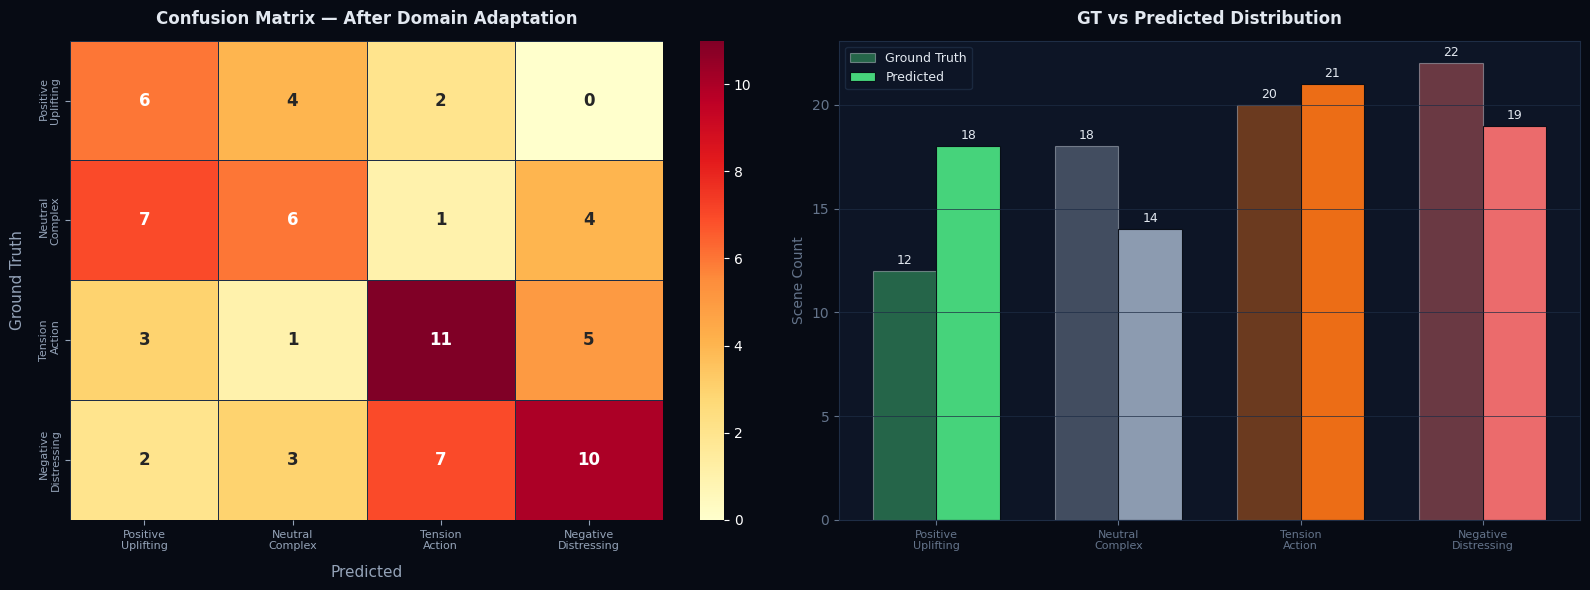

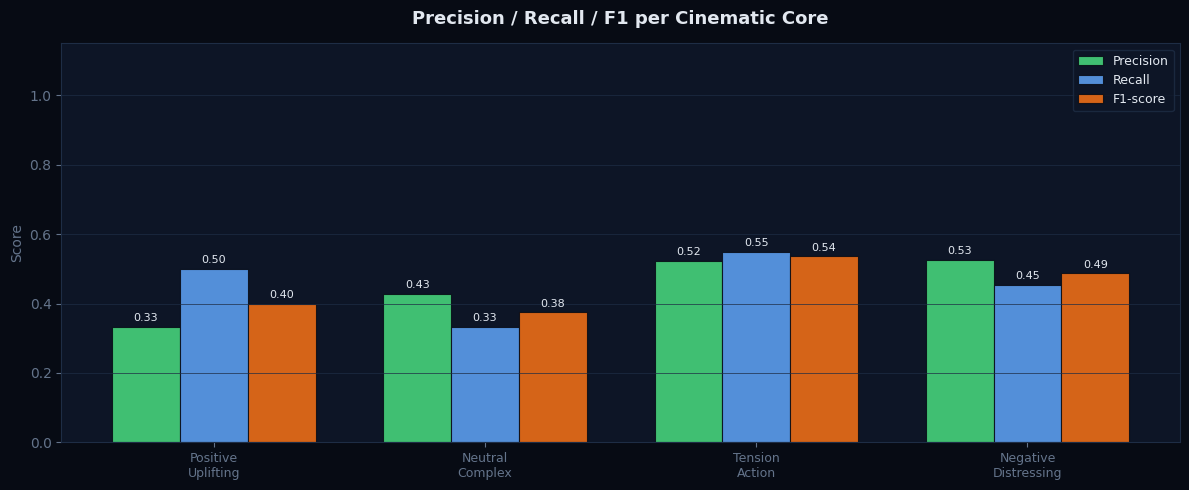


── Before vs After Domain Adaptation ──
  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22
  After  (Summer + Avatar + Avengers DA)  : Accuracy=45.8%  Macro F1=0.4498

✓ Adapted model saved: /kaggle/working/best_model_adapted.pt


In [2]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════
import json, math, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Config
# ═══════════════════════════════════════════════════════════════
MAX_LEN          = 128
BATCH_SIZE       = 8
DA_EPOCHS        = 40
PATIENCE         = 7
DA_DROPOUT       = 0.4
EMBED_DIM        = 768
NUM_HEADS        = 8
FF_DIM           = 2048
DROPOUT          = 0.2        # must match base model training
NUM_CLASSES      = 9          # base model GoEmotions output size

CORE_ORDER       = ["Positive_Uplifting", "Neutral_Complex",
                    "Tension_Action",     "Negative_Distressing"]
CORE_TO_IDX      = {c: i for i, c in enumerate(CORE_ORDER)}
NUM_CORE_CLASSES = len(CORE_ORDER)

CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

# ── Paths ──
MODEL_PATH         = "/kaggle/input/models/harshalkarangale/cl-encoder-freeze/pytorch/default/1/best_model_freeze.pt"
SUMMER_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"
AVATAR_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/avatar_scenes_only.json"
AVENGERS_PATH = "/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json"
ADAPTED_MODEL_PATH = "/kaggle/working/best_model_adapted.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════
#  CELL 3 — JSON loader
# ═══════════════════════════════════════════════════════════════
def load_script_json(path, name=""):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()
    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)
    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])
    scenes = []
    for s in data:
        text = str(s.get("scene_text", "")).strip()
        core = s.get("emotional_core")
        if text and core is not None:
            scenes.append({
                "text"  : text,
                "core"  : core.strip(),
                "source": name
            })
    return scenes

summer_scenes   = load_script_json(SUMMER_PATH,   "Summer")
avatar_scenes   = load_script_json(AVATAR_PATH,   "Avatar")
avengers_scenes = load_script_json(AVENGERS_PATH, "Avengers")

print(f"500 Days of Summer : {len(summer_scenes)} scenes")
print(f"Avatar             : {len(avatar_scenes)} scenes")
print(f"Avengers           : {len(avengers_scenes)} scenes")
print(f"Total              : {len(summer_scenes)+len(avatar_scenes)+len(avengers_scenes)} scenes")

# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Extended core mapping + Stratified 80/20 split
# ═══════════════════════════════════════════════════════════════

# Map any extra labels found in Avengers (or other scripts)
# to one of our 4 canonical cores
EXTENDED_CORE_MAP = {
    # Already valid — pass through
    "Positive_Uplifting"   : "Positive_Uplifting",
    "Neutral_Complex"      : "Neutral_Complex",
    "Tension_Action"       : "Tension_Action",
    "Negative_Distressing" : "Negative_Distressing",

    # Avengers extras
    "Awe_Wonder"           : "Positive_Uplifting",
    "Heroic_Triumph"       : "Positive_Uplifting",
    "Epic_Grandiose"       : "Tension_Action",
    "Dread_Fear"           : "Negative_Distressing",
    "Sacrifice"            : "Negative_Distressing",
    "Grief_Loss"           : "Negative_Distressing",
    "Anger_Defiance"       : "Tension_Action",
    "Suspense_Unease"      : "Tension_Action",
    "Determination"        : "Tension_Action",
    "Relief_Catharsis"     : "Positive_Uplifting",
    "Melancholy_Longing"   : "Negative_Distressing",
    "Humor_Levity"         : "Positive_Uplifting",
    "Shock_Disbelief"      : "Negative_Distressing",
    "Camaraderie_Bonding"  : "Positive_Uplifting",
    "Urgency_Desperation"  : "Tension_Action",

    # annoyance → Negative_Distressing (not Tension_Action)
    "annoyance"            : "Negative_Distressing",
}

def map_core(raw_core):
    """Map raw emotional_core to one of our 4 canonical cores."""
    raw = raw_core.strip()
    if raw in EXTENDED_CORE_MAP:
        return EXTENDED_CORE_MAP[raw]
    return None   # unknown — will be filtered out

# Apply mapping to all scenes
all_raw    = summer_scenes + avatar_scenes + avengers_scenes
all_scenes = []
skipped    = Counter()

for s in all_raw:
    mapped = map_core(s["core"])
    if mapped is not None:
        all_scenes.append({
            "text"  : s["text"],
            "core"  : mapped,
            "source": s["source"]
        })
    else:
        skipped[s["core"]] += 1

if skipped:
    print(f"⚠ Skipped {sum(skipped.values())} scenes with unmapped cores: {dict(skipped)}")
print(f"✓ Total usable scenes after mapping: {len(all_scenes)}")
print(f"  Combined dist: {Counter(s['core'] for s in all_scenes)}")

all_texts  = [s["text"]   for s in all_scenes]
all_labels = [s["core"]   for s in all_scenes]
all_source = [s["source"] for s in all_scenes]

train_texts, test_texts, train_labels, test_labels, train_src, test_src = train_test_split(
    all_texts, all_labels, all_source,
    test_size    = 0.2,
    stratify     = all_labels,
    random_state = 42
)

print(f"\nTrain : {len(train_texts)} scenes")
print(f"Test  : {len(test_texts)}  scenes")

print(f"\nTrain dist : {Counter(train_labels)}")
print(f"Test  dist : {Counter(test_labels)}")

print(f"\nTest source breakdown:")
test_src_core = Counter(zip(test_src, test_labels))
for (src, core), count in sorted(test_src_core.items()):
    print(f"  {src:10s} | {core:25s} : {count}")

# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Base model architecture (exact match to training)
# ═══════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.head_dim  = embed_dim // num_heads
        self.num_heads = num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q       = nn.Linear(embed_dim, embed_dim)
        self.W_k       = nn.Linear(embed_dim, embed_dim)
        self.W_v       = nn.Linear(embed_dim, embed_dim)
        self.W_o       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, E = x.shape
        def split(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores   = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, E)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, heads=NUM_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(embed_dim, heads, dropout)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Tanh(), nn.Linear(256, 1)
        )
    def forward(self, x, mask=None):
        scores = self.scorer(x)
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, None] == 0, float("-inf"))
        return (torch.softmax(scores, dim=1) * x).sum(dim=1)


class EmotionTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.enc1       = TransformerEncoderLayer()
        self.enc2       = TransformerEncoderLayer()
        self.pool       = AttentionPooling()
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )
    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))

# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Adapted model (4-class head)
# ═══════════════════════════════════════════════════════════════
class AdaptedEmotionModel(nn.Module):
    def __init__(self, base, num_classes=NUM_CORE_CLASSES):
        super().__init__()
        self.bert = base.bert
        self.enc1 = base.enc1
        self.enc2 = base.enc2
        self.pool = base.pool
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 256), nn.GELU(),
            nn.Dropout(DA_DROPOUT),   nn.Linear(256, num_classes)
        )
        # Freeze bottom 8 BERT layers
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        for i in range(8):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
        # Top 4 BERT layers trainable
        for i in range(8, 12):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))


tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
base_model = EmotionTransformer(num_classes=NUM_CLASSES).to(device)
state      = torch.load(MODEL_PATH, map_location=device, weights_only=True)
base_model.load_state_dict(state)

da_model   = AdaptedEmotionModel(base_model).to(device)
total      = sum(p.numel() for p in da_model.parameters())
trainable  = sum(p.numel() for p in da_model.parameters() if p.requires_grad)
print(f"✓ Adapted model ready")
print(f"  Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)")

# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Dataset + DataLoaders
# ═══════════════════════════════════════════════════════════════
class CoreDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = [str(t) for t in texts]
        self.labels = [CORE_TO_IDX[l] for l in labels]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], padding="max_length",
            truncation=True, max_length=MAX_LEN, return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_loader_da = DataLoader(CoreDataset(train_texts, train_labels),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
test_loader_da  = DataLoader(CoreDataset(test_texts, test_labels),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

# ═══════════════════════════════════════════════════════════════
#  CELL 8 — Loss + Optimizer + Scheduler
# ═══════════════════════════════════════════════════════════════
train_dist  = Counter(train_labels)
total_train = len(train_labels)
weights     = torch.tensor(
    [total_train / (NUM_CORE_CLASSES * train_dist.get(c, 1)) for c in CORE_ORDER],
    dtype=torch.float
).to(device)
print(f"Class weights: { {c: round(w.item(), 2) for c, w in zip(CORE_ORDER, weights)} }")

criterion_da = nn.CrossEntropyLoss(weight=weights)

bert_top_params = (list(da_model.bert.encoder.layer[8:].parameters()) +
                   list(da_model.bert.pooler.parameters()))
custom_params   = (list(da_model.enc1.parameters()) +
                   list(da_model.enc2.parameters()) +
                   list(da_model.pool.parameters()) +
                   list(da_model.classifier.parameters()))

optimizer_da = optim.AdamW([
    {"params": bert_top_params, "lr": 1e-5, "weight_decay": 0.01},
    {"params": custom_params,   "lr": 5e-5, "weight_decay": 0.01},
])

total_steps  = len(train_loader_da) * DA_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler_da = get_cosine_schedule_with_warmup(optimizer_da, warmup_steps, total_steps)

# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Train / Eval functions
# ═══════════════════════════════════════════════════════════════
def da_train_epoch():
    da_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for input_ids, mask, labels in train_loader_da:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        optimizer_da.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(da_model.parameters(), 1.0)
        optimizer_da.step()
        scheduler_da.step()
        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(train_loader_da), correct / total


@torch.no_grad()
def da_eval_epoch(loader):
    da_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for input_ids, mask, labels in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.cpu().tolist()
    pred_names  = [CORE_ORDER[p] for p in all_preds]
    label_names = [CORE_ORDER[l] for l in all_labels]
    macro_f1    = f1_score(label_names, pred_names,
                           labels=CORE_ORDER, average="macro", zero_division=0)
    return total_loss / len(loader), correct / total, macro_f1, pred_names, label_names

# ═══════════════════════════════════════════════════════════════
#  CELL 10 — Training loop
# ═══════════════════════════════════════════════════════════════
print(f"── Domain Adaptation Training ──")
print(f"   Train: {len(train_texts)} | Test: {len(test_texts)}\n")

best_f1_da, best_state_da, patience_counter = 0.0, None, 0

for epoch in range(1, DA_EPOCHS + 1):
    tr_loss, tr_acc                        = da_train_epoch()
    te_loss, te_acc, te_f1, preds, labels  = da_eval_epoch(test_loader_da)
    gap = tr_acc - te_acc

    print(f"Epoch {epoch:2d}/{DA_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
          f"test_loss={te_loss:.4f}  test_acc={te_acc:.3f}  "
          f"macro_f1={te_f1:.4f}  gap={gap:.3f}")

    if te_f1 > best_f1_da:
        best_f1_da       = te_f1
        best_state_da    = {k: v.cpu().clone() for k, v in da_model.state_dict().items()}
        patience_counter = 0
        torch.save(best_state_da, ADAPTED_MODEL_PATH)
        print(f"  ✓ New best saved  (macro_f1={best_f1_da:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ═══════════════════════════════════════════════════════════════
#  CELL 11 — Final evaluation + all plots
# ═══════════════════════════════════════════════════════════════
print("\n── Final Test Evaluation ──")
da_model.load_state_dict({k: v.to(device) for k, v in best_state_da.items()})
_, test_acc, test_f1, pred_names, label_names = da_eval_epoch(test_loader_da)

print(f"Accuracy  : {test_acc*100:.1f}%")
print(f"Macro F1  : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(label_names, pred_names,
                             labels=CORE_ORDER, zero_division=0))

plt.style.use("dark_background")

# ── Plot 1: Confusion Matrix ──
cm  = confusion_matrix(label_names, pred_names, labels=CORE_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#070b14")

ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix — After Domain Adaptation",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── Plot 2: GT vs Predicted distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(label_names)
pred_dist = Counter(pred_names)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]

b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count",   color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/da_results.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

# ── Plot 3: Per-class F1 bar chart ──
report_dict = classification_report(
    label_names, pred_names, labels=CORE_ORDER,
    zero_division=0, output_dict=True
)
metrics       = ["precision", "recall", "f1-score"]
metric_colors = ["#4ade80",   "#60a5fa", "#f97316"]
x             = np.arange(len(CORE_ORDER))
bw            = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#070b14")
ax.set_facecolor("#0d1526")
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report_dict[c][metric] for c in CORE_ORDER]
    bars = ax.bar(x + i * bw, vals, bw, label=metric.capitalize(),
                  color=color, alpha=0.85, edgecolor="#070b14", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=8, color="#e2e8f0")

ax.set_xticks(x + bw)
ax.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                   fontsize=9, color="#94a3b8")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", color="#64748b", fontsize=10)
ax.set_title("Precision / Recall / F1 per Cinematic Core",
             color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(colors="#64748b")
ax.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/per_class_f1.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

print(f"\n── Before vs After Domain Adaptation ──")
print(f"  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22")
print(f"  After  (Summer + Avatar + Avengers DA)  : Accuracy={test_acc*100:.1f}%  Macro F1={test_f1:.4f}")
print(f"\n✓ Adapted model saved: {ADAPTED_MODEL_PATH}")

Multilabel dtaset

Device: cuda
Avengers scenes loaded : 172
✓ Usable Avengers scenes: 172
Core distribution:
Counter({'Tension_Action': 65, 'Negative_Distressing': 46, 'Neutral_Complex': 36, 'Positive_Uplifting': 25})

Train scenes : 137
Test scenes  : 35

Train distribution:
Counter({'Tension_Action': 52, 'Negative_Distressing': 36, 'Neutral_Complex': 29, 'Positive_Uplifting': 20})

Test distribution:
Counter({'Tension_Action': 13, 'Negative_Distressing': 10, 'Neutral_Complex': 7, 'Positive_Uplifting': 5})


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Adapted model ready
  Trainable: 40,365,061 / 120,905,221  (33.4%)
Class weights: {'Positive_Uplifting': 1.71, 'Neutral_Complex': 1.18, 'Tension_Action': 0.66, 'Negative_Distressing': 0.95}
── Domain Adaptation Training ──
   Train: 137 | Test: 35

Epoch  1/40  train_loss=1.3952  train_acc=0.190  test_loss=1.3919  test_acc=0.286  macro_f1=0.1806  gap=-0.096
  ✓ New best saved  (macro_f1=0.1806)
Epoch  2/40  train_loss=1.3974  train_acc=0.226  test_loss=1.3916  test_acc=0.286  macro_f1=0.1136  gap=-0.059
Epoch  3/40  train_loss=1.3864  train_acc=0.263  test_loss=1.3901  test_acc=0.286  macro_f1=0.1190  gap=-0.023
Epoch  4/40  train_loss=1.3826  train_acc=0.285  test_loss=1.3910  test_acc=0.286  macro_f1=0.1190  gap=-0.001
Epoch  5/40  train_loss=1.3754  train_acc=0.314  test_loss=1.3906  test_acc=0.314  macro_f1=0.1772  gap=-0.000
Epoch  6/40  train_loss=1.3650  train_acc=0.416  test_loss=1.3899  test_acc=0.314  macro_f1=0.1742  gap=0.102
Epoch  7/40  train_loss=1.3610  train_acc=0.34

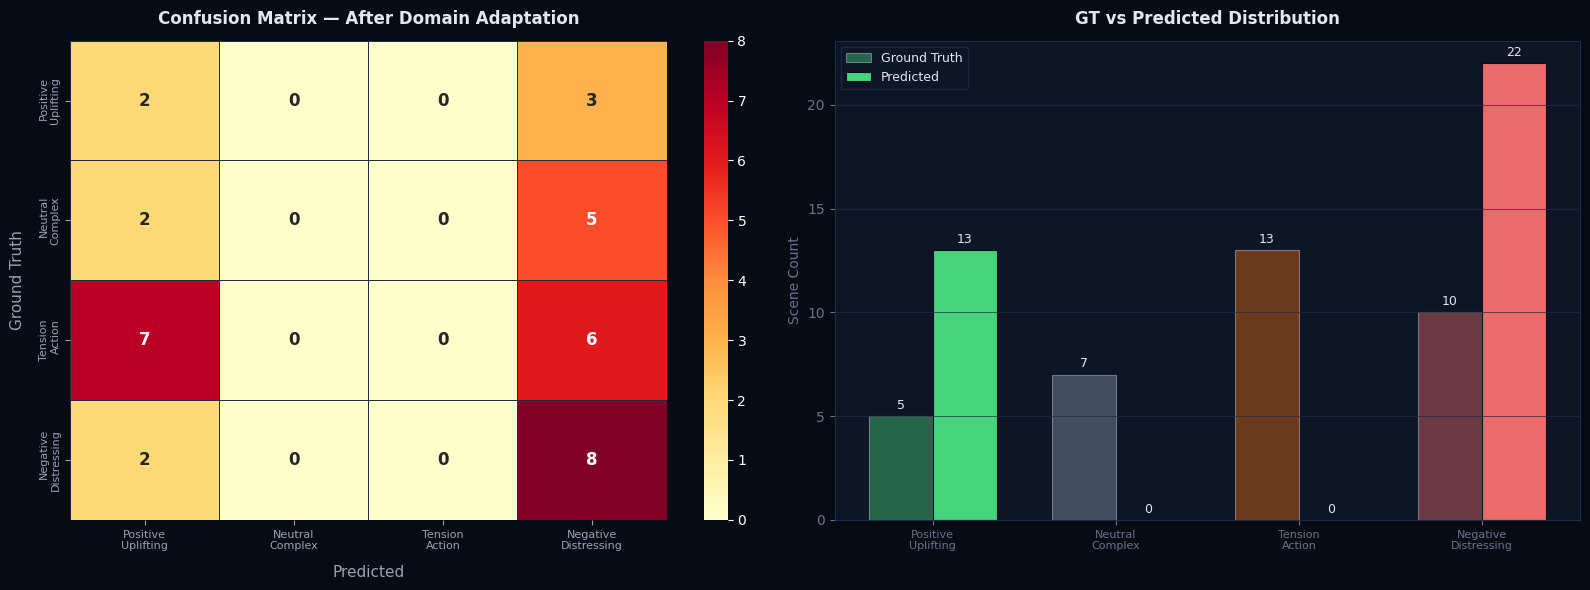

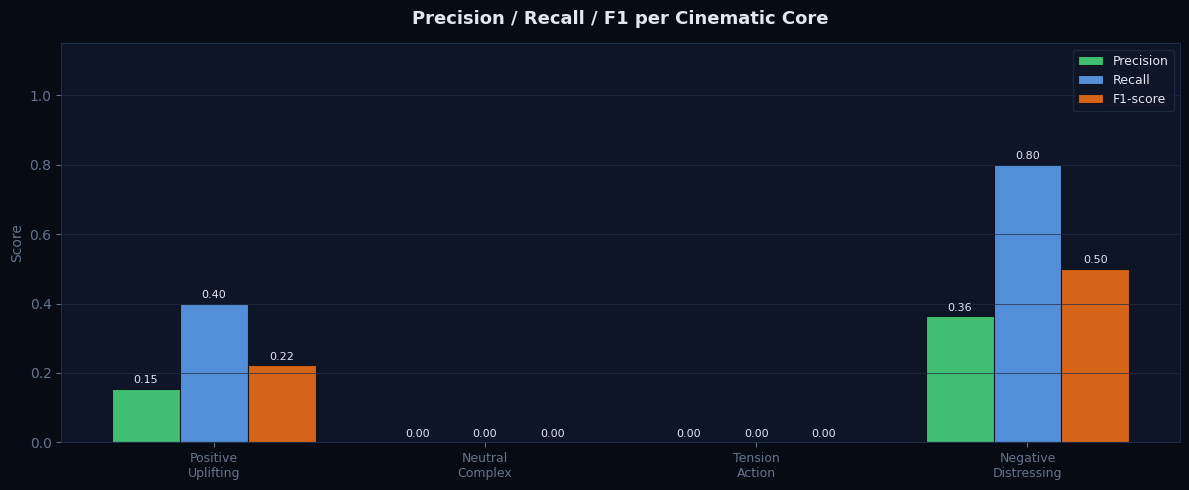


── Before vs After Domain Adaptation ──
  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22
  After  (Summer + Avatar + Avengers DA)  : Accuracy=28.6%  Macro F1=0.1806

✓ Adapted model saved: /kaggle/working/best_model_adapted.pt


In [2]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Imports
# ═══════════════════════════════════════════════════════════════
import json, math, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Config
# ═══════════════════════════════════════════════════════════════
MAX_LEN          = 128
BATCH_SIZE       = 8
DA_EPOCHS        = 40
PATIENCE         = 7
DA_DROPOUT       = 0.4
EMBED_DIM        = 768
NUM_HEADS        = 8
FF_DIM           = 2048
DROPOUT          = 0.2        # must match base model training
NUM_CLASSES      = 9          # base model GoEmotions output size

CORE_ORDER       = ["Positive_Uplifting", "Neutral_Complex",
                    "Tension_Action",     "Negative_Distressing"]
CORE_TO_IDX      = {c: i for i, c in enumerate(CORE_ORDER)}
NUM_CORE_CLASSES = len(CORE_ORDER)

CORE_COLORS = {
    "Positive_Uplifting"   : "#4ade80",
    "Neutral_Complex"      : "#94a3b8",
    "Tension_Action"       : "#f97316",
    "Negative_Distressing" : "#f87171",
}

# ── Paths ──
MODEL_PATH         = "/kaggle/input/models/harshalkarangale/cl-encoder-freeze/pytorch/default/1/best_model_freeze.pt"
SUMMER_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/500_summer_scenes_only.json"
AVATAR_PATH   = "/kaggle/input/datasets/harshalkarangale/script1/avatar_scenes_only.json"
AVENGERS_PATH = "/kaggle/input/datasets/harshalkarangale/avengerss/avengers_scenes_only.json"
ADAPTED_MODEL_PATH = "/kaggle/working/best_model_adapted.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ═══════════════════════════════════════════════════════════════
#  CELL 3 — JSON loader (Avengers only)
# ═══════════════════════════════════════════════════════════════
def load_script_json(path, name=""):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().strip()

    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        raw  = "[" + raw + "]"
        raw  = re.sub(r',\s*\]', ']', raw)
        data = json.loads(raw)

    if isinstance(data, dict):
        data = data.get("scenes", list(data.values())[0])

    scenes = []
    for s in data:
        text = str(s.get("scene_text", "")).strip()
        core = s.get("emotional_core")

        if text and core is not None:
            scenes.append({
                "text": text,
                "core": core.strip(),
                "source": name
            })

    return scenes


# Load ONLY Avengers
avengers_scenes = load_script_json(AVENGERS_PATH, "Avengers")

print(f"Avengers scenes loaded : {len(avengers_scenes)}")


# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Core mapping + Balanced Stratified Split (Avengers only)
# ═══════════════════════════════════════════════════════════════

EXTENDED_CORE_MAP = {
    "Positive_Uplifting"   : "Positive_Uplifting",
    "Neutral_Complex"      : "Neutral_Complex",
    "Tension_Action"       : "Tension_Action",
    "Negative_Distressing" : "Negative_Distressing",

    "Awe_Wonder"           : "Positive_Uplifting",
    "Heroic_Triumph"       : "Positive_Uplifting",
    "Epic_Grandiose"       : "Tension_Action",
    "Dread_Fear"           : "Negative_Distressing",
    "Sacrifice"            : "Negative_Distressing",
    "Grief_Loss"           : "Negative_Distressing",
    "Anger_Defiance"       : "Tension_Action",
    "Suspense_Unease"      : "Tension_Action",
    "Determination"        : "Tension_Action",
    "Relief_Catharsis"     : "Positive_Uplifting",
    "Melancholy_Longing"   : "Negative_Distressing",
    "Humor_Levity"         : "Positive_Uplifting",
    "Shock_Disbelief"      : "Negative_Distressing",
    "Camaraderie_Bonding"  : "Positive_Uplifting",
    "Urgency_Desperation"  : "Tension_Action",

    "annoyance"            : "Negative_Distressing",
}


def map_core(raw_core):
    raw = raw_core.strip()
    if raw in EXTENDED_CORE_MAP:
        return EXTENDED_CORE_MAP[raw]
    return None


# Apply mapping
all_scenes = []
skipped = Counter()

for s in avengers_scenes:

    mapped = map_core(s["core"])

    if mapped is not None:
        all_scenes.append({
            "text": s["text"],
            "core": mapped,
            "source": "Avengers"
        })
    else:
        skipped[s["core"]] += 1


if skipped:
    print(f"⚠ Skipped {sum(skipped.values())} scenes: {dict(skipped)}")

print(f"✓ Usable Avengers scenes: {len(all_scenes)}")

print(f"Core distribution:")
print(Counter(s["core"] for s in all_scenes))


# Prepare lists
all_texts  = [s["text"] for s in all_scenes]
all_labels = [s["core"] for s in all_scenes]
all_source = ["Avengers"] * len(all_scenes)


# Stratified balanced split
train_texts, test_texts, train_labels, test_labels = train_test_split(
    all_texts,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

train_src = ["Avengers"] * len(train_texts)
test_src  = ["Avengers"] * len(test_texts)


print(f"\nTrain scenes : {len(train_texts)}")
print(f"Test scenes  : {len(test_texts)}")

print("\nTrain distribution:")
print(Counter(train_labels))

print("\nTest distribution:")
print(Counter(test_labels))

# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Base model architecture (exact match to training)
# ═══════════════════════════════════════════════════════════════
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        super().__init__()
        self.head_dim  = embed_dim // num_heads
        self.num_heads = num_heads
        self.scale     = math.sqrt(self.head_dim)
        self.W_q       = nn.Linear(embed_dim, embed_dim)
        self.W_k       = nn.Linear(embed_dim, embed_dim)
        self.W_v       = nn.Linear(embed_dim, embed_dim)
        self.W_o       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, E = x.shape
        def split(t):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split(self.W_q(x)), split(self.W_k(x)), split(self.W_v(x))
        scores   = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask[:, None, None, :] == 0, float("-inf"))
        weights = self.attn_drop(torch.softmax(scores, dim=-1))
        out     = torch.matmul(weights, V).transpose(1, 2).contiguous().view(B, T, E)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)


class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, heads=NUM_HEADS,
                 ff_dim=FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(embed_dim, heads, dropout)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attn(x, mask))
        x = self.norm2(x + self.ff(x))
        return x


class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.Tanh(), nn.Linear(256, 1)
        )
    def forward(self, x, mask=None):
        scores = self.scorer(x)
        if mask is not None:
            scores = scores.masked_fill(mask[:, :, None] == 0, float("-inf"))
        return (torch.softmax(scores, dim=1) * x).sum(dim=1)


class EmotionTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.enc1       = TransformerEncoderLayer()
        self.enc2       = TransformerEncoderLayer()
        self.pool       = AttentionPooling()
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 512), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )
    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))

# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Adapted model (4-class head)
# ═══════════════════════════════════════════════════════════════
class AdaptedEmotionModel(nn.Module):
    def __init__(self, base, num_classes=NUM_CORE_CLASSES):
        super().__init__()
        self.bert = base.bert
        self.enc1 = base.enc1
        self.enc2 = base.enc2
        self.pool = base.pool
        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 256), nn.GELU(),
            nn.Dropout(DA_DROPOUT),   nn.Linear(256, num_classes)
        )
        # Freeze bottom 8 BERT layers
        for param in self.bert.embeddings.parameters():
            param.requires_grad = False
        for i in range(8):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = False
        # Top 4 BERT layers trainable
        for i in range(8, 12):
            for param in self.bert.encoder.layer[i].parameters():
                param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        x      = self.bert(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state
        x      = self.enc1(x, mask=attention_mask)
        x      = self.enc2(x, mask=attention_mask)
        return self.classifier(self.pool(x, mask=attention_mask))


tokenizer  = BertTokenizer.from_pretrained("bert-base-uncased")
base_model = EmotionTransformer(num_classes=NUM_CLASSES).to(device)
state      = torch.load(MODEL_PATH, map_location=device, weights_only=True)
base_model.load_state_dict(state)

da_model   = AdaptedEmotionModel(base_model).to(device)
total      = sum(p.numel() for p in da_model.parameters())
trainable  = sum(p.numel() for p in da_model.parameters() if p.requires_grad)
print(f"✓ Adapted model ready")
print(f"  Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)")

# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Dataset + DataLoaders
# ═══════════════════════════════════════════════════════════════
class CoreDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = [str(t) for t in texts]
        self.labels = [CORE_TO_IDX[l] for l in labels]
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx], padding="max_length",
            truncation=True, max_length=MAX_LEN, return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_loader_da = DataLoader(CoreDataset(train_texts, train_labels),
                              batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
test_loader_da  = DataLoader(CoreDataset(test_texts, test_labels),
                              batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)

# ═══════════════════════════════════════════════════════════════
#  CELL 8 — Loss + Optimizer + Scheduler
# ═══════════════════════════════════════════════════════════════
train_dist  = Counter(train_labels)
total_train = len(train_labels)
weights     = torch.tensor(
    [total_train / (NUM_CORE_CLASSES * train_dist.get(c, 1)) for c in CORE_ORDER],
    dtype=torch.float
).to(device)
print(f"Class weights: { {c: round(w.item(), 2) for c, w in zip(CORE_ORDER, weights)} }")

criterion_da = nn.CrossEntropyLoss(weight=weights)

bert_top_params = (list(da_model.bert.encoder.layer[8:].parameters()) +
                   list(da_model.bert.pooler.parameters()))
custom_params   = (list(da_model.enc1.parameters()) +
                   list(da_model.enc2.parameters()) +
                   list(da_model.pool.parameters()) +
                   list(da_model.classifier.parameters()))

optimizer_da = optim.AdamW([
    {"params": bert_top_params, "lr": 1e-5, "weight_decay": 0.01},
    {"params": custom_params,   "lr": 5e-5, "weight_decay": 0.01},
])

total_steps  = len(train_loader_da) * DA_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler_da = get_cosine_schedule_with_warmup(optimizer_da, warmup_steps, total_steps)

# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Train / Eval functions
# ═══════════════════════════════════════════════════════════════
def da_train_epoch():
    da_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for input_ids, mask, labels in train_loader_da:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        optimizer_da.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(da_model.parameters(), 1.0)
        optimizer_da.step()
        scheduler_da.step()
        total_loss += loss.item()
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(train_loader_da), correct / total


@torch.no_grad()
def da_eval_epoch(loader):
    da_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for input_ids, mask, labels in loader:
        input_ids = input_ids.to(device)
        mask      = mask.to(device)
        labels    = labels.to(device)
        logits    = da_model(input_ids, mask)
        loss      = criterion_da(logits, labels)
        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        all_preds  += preds.cpu().tolist()
        all_labels += labels.cpu().tolist()
    pred_names  = [CORE_ORDER[p] for p in all_preds]
    label_names = [CORE_ORDER[l] for l in all_labels]
    macro_f1    = f1_score(label_names, pred_names,
                           labels=CORE_ORDER, average="macro", zero_division=0)
    return total_loss / len(loader), correct / total, macro_f1, pred_names, label_names

# ═══════════════════════════════════════════════════════════════
#  CELL 10 — Training loop
# ═══════════════════════════════════════════════════════════════
print(f"── Domain Adaptation Training ──")
print(f"   Train: {len(train_texts)} | Test: {len(test_texts)}\n")

best_f1_da, best_state_da, patience_counter = 0.0, None, 0

for epoch in range(1, DA_EPOCHS + 1):
    tr_loss, tr_acc                        = da_train_epoch()
    te_loss, te_acc, te_f1, preds, labels  = da_eval_epoch(test_loader_da)
    gap = tr_acc - te_acc

    print(f"Epoch {epoch:2d}/{DA_EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.3f}  "
          f"test_loss={te_loss:.4f}  test_acc={te_acc:.3f}  "
          f"macro_f1={te_f1:.4f}  gap={gap:.3f}")

    if te_f1 > best_f1_da:
        best_f1_da       = te_f1
        best_state_da    = {k: v.cpu().clone() for k, v in da_model.state_dict().items()}
        patience_counter = 0
        torch.save(best_state_da, ADAPTED_MODEL_PATH)
        print(f"  ✓ New best saved  (macro_f1={best_f1_da:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

# ═══════════════════════════════════════════════════════════════
#  CELL 11 — Final evaluation + all plots
# ═══════════════════════════════════════════════════════════════
print("\n── Final Test Evaluation ──")
da_model.load_state_dict({k: v.to(device) for k, v in best_state_da.items()})
_, test_acc, test_f1, pred_names, label_names = da_eval_epoch(test_loader_da)

print(f"Accuracy  : {test_acc*100:.1f}%")
print(f"Macro F1  : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(label_names, pred_names,
                             labels=CORE_ORDER, zero_division=0))

plt.style.use("dark_background")

# ── Plot 1: Confusion Matrix ──
cm  = confusion_matrix(label_names, pred_names, labels=CORE_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#070b14")

ax = axes[0]
ax.set_facecolor("#0d1526")
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    yticklabels=[c.replace("_", "\n") for c in CORE_ORDER],
    ax=ax, linewidths=0.5, linecolor="#1e2d45",
    annot_kws={"size": 12, "weight": "bold"}
)
ax.set_xlabel("Predicted",    color="#94a3b8", fontsize=11, labelpad=10)
ax.set_ylabel("Ground Truth", color="#94a3b8", fontsize=11, labelpad=10)
ax.set_title("Confusion Matrix — After Domain Adaptation",
             color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax.tick_params(colors="#94a3b8", labelsize=8)

# ── Plot 2: GT vs Predicted distribution ──
ax2 = axes[1]
ax2.set_facecolor("#0d1526")
gt_dist   = Counter(label_names)
pred_dist = Counter(pred_names)
x         = np.arange(len(CORE_ORDER))
bw        = 0.35
gt_vals   = [gt_dist.get(c, 0)   for c in CORE_ORDER]
pred_vals = [pred_dist.get(c, 0) for c in CORE_ORDER]

b1 = ax2.bar(x - bw/2, gt_vals,   bw, label="Ground Truth",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.4, edgecolor="#e2e8f0", linewidth=0.8)
b2 = ax2.bar(x + bw/2, pred_vals, bw, label="Predicted",
             color=[CORE_COLORS[c] for c in CORE_ORDER],
             alpha=0.95, edgecolor="#070b14", linewidth=0.8)
for bar, val in zip(list(b1) + list(b2), gt_vals + pred_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9, color="#e2e8f0")
ax2.set_xticks(x)
ax2.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                    fontsize=8, color="#94a3b8")
ax2.set_ylabel("Scene Count",   color="#64748b", fontsize=10)
ax2.set_title("GT vs Predicted Distribution",
              color="#e2e8f0", fontsize=12, fontweight="bold", pad=12)
ax2.tick_params(colors="#64748b")
ax2.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax2.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/da_results.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

# ── Plot 3: Per-class F1 bar chart ──
report_dict = classification_report(
    label_names, pred_names, labels=CORE_ORDER,
    zero_division=0, output_dict=True
)
metrics       = ["precision", "recall", "f1-score"]
metric_colors = ["#4ade80",   "#60a5fa", "#f97316"]
x             = np.arange(len(CORE_ORDER))
bw            = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#070b14")
ax.set_facecolor("#0d1526")
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report_dict[c][metric] for c in CORE_ORDER]
    bars = ax.bar(x + i * bw, vals, bw, label=metric.capitalize(),
                  color=color, alpha=0.85, edgecolor="#070b14", linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=8, color="#e2e8f0")

ax.set_xticks(x + bw)
ax.set_xticklabels([c.replace("_", "\n") for c in CORE_ORDER],
                   fontsize=9, color="#94a3b8")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", color="#64748b", fontsize=10)
ax.set_title("Precision / Recall / F1 per Cinematic Core",
             color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(colors="#64748b")
ax.legend(fontsize=9, facecolor="#0d1526", edgecolor="#1e2d45", labelcolor="#e2e8f0")
ax.grid(axis="y", color="#1e2d45", linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e2d45")

plt.tight_layout()
plt.savefig("/kaggle/working/per_class_f1.png",
            dpi=150, bbox_inches="tight", facecolor="#070b14")
plt.show()

print(f"\n── Before vs After Domain Adaptation ──")
print(f"  Before (GoEmotions only)                : Accuracy=34.0%  Macro F1=0.22")
print(f"  After  (Summer + Avatar + Avengers DA)  : Accuracy={test_acc*100:.1f}%  Macro F1={test_f1:.4f}")
print(f"\n✓ Adapted model saved: {ADAPTED_MODEL_PATH}")